**DAY1**

In [ ]:
# Simple Calculator

print("----- SIMPLE CALCULATOR -----")

# Input from user
num1 = float(input("Enter first number: "))
num2 = float(input("Enter second number: "))

# Operations
addition = num1 + num2
subtraction = num1 - num2
multiplication = num1 * num2

# Handle division safely
if num2 != 0:
    division = num1 / num2
else:
    division = "Undefined (cannot divide by zero)"

# Output results
print("\n----- RESULTS -----")
print("Addition: ", addition)
print("Subtraction: ", subtraction)
print("Multiplication: ", multiplication)
print("Division: ", division)

----- SIMPLE CALCULATOR -----
Enter first number: 15
Enter second number: 45

----- RESULTS -----
Addition:  60.0
Subtraction:  -30.0
Multiplication:  675.0
Division:  0.3333333333333333


**DAY2**

In [ ]:
import random

print("===== MINI PROJECT LAB =====")

while True:
    print("\nChoose an option:")
    print("1. Number Guessing Game")
    print("2. Student Grade Report Generator")
    print("3. Exit")

    choice = input("Enter your choice (1/2/3): ")

    # -----------------------------
    # 1. NUMBER GUESSING GAME
    # -----------------------------
    if choice == "1":
        print("\n----- NUMBER GUESSING GAME -----")
        secret_number = random.randint(1, 20)
        attempts = 0

        while True:
            guess = int(input("Guess a number (1 to 20): "))
            attempts += 1

            if guess < secret_number:
                print("Too low!")
            elif guess > secret_number:
                print("📈Too high!")
            else:
                print(f"Correct! You guessed in {attempts} attempts.")
                break

    # -----------------------------
    # 2. STUDENT GRADE REPORT
    # -----------------------------
    elif choice == "2":
        print("\n----- STUDENT GRADE REPORT -----")

        name = input("Enter student name: ")
        roll_no = input("Enter roll number: ")

        math = float(input("Enter Maths marks: "))
        science = float(input("Enter Science marks: "))
        english = float(input("Enter English marks: "))

        total = math + science + english
        average = total / 3

        if average >= 90:
            grade = "A+"
        elif average >= 75:
            grade = "A"
        elif average >= 60:
            grade = "B"
        elif average >= 40:
            grade = "C"
        else:
            grade = "Fail"

        print("\n----- REPORT CARD -----")
        print("Name:", name)
        print("Roll No:", roll_no)
        print("Total Marks:", total)
        print("Average:", average)
        print("Grade:", grade)

    # -----------------------------
    # EXIT
    # -----------------------------
    elif choice == "3":
        print("Exiting program... Goodbye!")
        break

    else:
        print("Invalid choice! Please select 1, 2, or 3.")

===== MINI PROJECT LAB =====

Choose an option:
1. Number Guessing Game
2. Student Grade Report Generator
3. Exit
Enter your choice (1/2/3): 2

----- STUDENT GRADE REPORT -----
Enter student name: teja
Enter roll number: 41
Enter Maths marks: 90
Enter Science marks: 98
Enter English marks: 92

----- REPORT CARD -----
Name: teja
Roll No: 41
Total Marks: 280.0
Average: 93.33333333333333
Grade: A+

Choose an option:
1. Number Guessing Game
2. Student Grade Report Generator
3. Exit
Enter your choice (1/2/3): 3
Exiting program... Goodbye!


**DAY3*

In [ ]:
import csv

# Function to calculate grade
def get_grade(avg):
    if avg >= 90:
        return "A+"
    elif avg >= 75:
        return "A"
    elif avg >= 60:
        return "B"
    elif avg >= 40:
        return "C"
    else:
        return "Fail"

input_file = "students.csv"
output_file = "report_card_output.csv"

students = []

# -----------------------------
# READ CSV FILE
# -----------------------------
with open(input_file, "r") as file:
    reader = csv.DictReader(file)

    for row in reader:
        name = row["name"]
        roll_no = row["roll_no"]

        maths = float(row["maths"])
        science = float(row["science"])
        english = float(row["english"])

        total = maths + science + english
        average = total / 3
        grade = get_grade(average)

        students.append({
            "name": name,
            "roll_no": roll_no,
            "total": total,
            "average": round(average, 2),
            "grade": grade
        })


with open(output_file, "w", newline="") as file:
    fieldnames = ["name", "roll_no", "total", "average", "grade"]
    writer = csv.DictWriter(file, fieldnames=fieldnames)

    writer.writeheader()
    writer.writerows(students)

print(" Report card generated successfully!")
print(f"Output file: {output_file}")

 Report card generated successfully!
Output file: report_card_output.csv


**DAY4**


1. Shape of dataset:
(6, 6)

2. Column names:
Index(['Date', 'State/UnionTerritory', 'Confirmed', 'Deaths', 'Recovered',
       'Active'],
      dtype='object')

3. Missing values:
Date                    0
State/UnionTerritory    0
Confirmed               0
Deaths                  0
Recovered               0
Active                  0
dtype: int64

4. Number of unique states:
2

5. State with highest confirmed cases:
State/UnionTerritory
Karnataka    180
Name: Confirmed, dtype: int64

6. Top 5 states by deaths:
State/UnionTerritory
Karnataka         5
Andhra Pradesh    4
Name: Deaths, dtype: int64

7. Total confirmed cases in India:
850

8. Daily confirmed cases trend:
Date
2021-01-01    250
2021-01-02    290
2021-01-03    310
Name: Confirmed, dtype: int64

9. Date with maximum cases:
2021-01-03 310

10. Correlation matrix:
           Confirmed    Deaths  Recovered
Confirmed   1.000000  0.841153   0.985890
Deaths      0.841153  1.000000   0.835229
Recovered   0.985890  0.835229   1.00

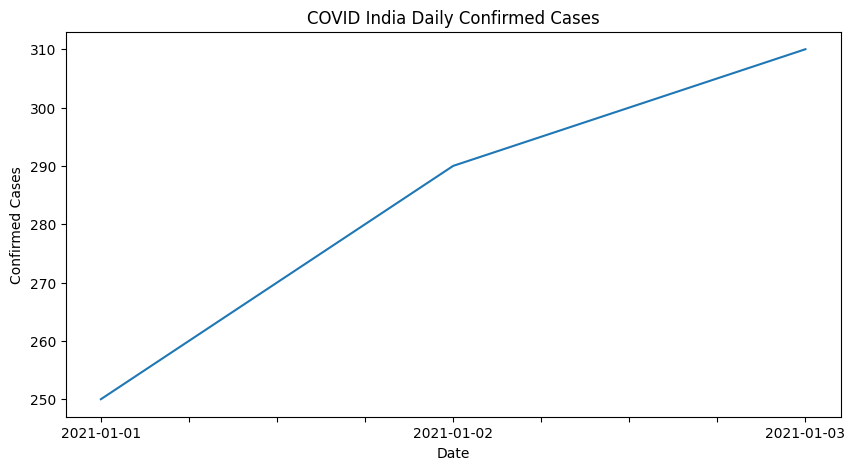

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("covid_india.csv")

print("\n1. Shape of dataset:")
print(df.shape)

print("\n2. Column names:")
print(df.columns)

print("\n3. Missing values:")
print(df.isnull().sum())

print("\n4. Number of unique states:")
print(df["State/UnionTerritory"].nunique())

print("\n5. State with highest confirmed cases:")
print(df.groupby("State/UnionTerritory")["Confirmed"].max().sort_values(ascending=False).head(1))

print("\n6. Top 5 states by deaths:")
print(df.groupby("State/UnionTerritory")["Deaths"].max().sort_values(ascending=False).head(5))

print("\n7. Total confirmed cases in India:")
print(df["Confirmed"].sum())

print("\n8. Daily confirmed cases trend:")
daily_cases = df.groupby("Date")["Confirmed"].sum()
print(daily_cases)

print("\n9. Date with maximum cases:")
print(daily_cases.idxmax(), daily_cases.max())

print("\n10. Correlation matrix:")
print(df[["Confirmed", "Deaths", "Recovered"]].corr())

# Bonus visualization
plt.figure(figsize=(10,5))
daily_cases.plot()
plt.title("COVID India Daily Confirmed Cases")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.show()

**DAY6**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
# nn 1. Create the Dataset nnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnn
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'pass_fail':     [0, 0, 0, 1, 1, 1, 1, 1, 1,  1]
}
df = pd.DataFrame(data)
print('Our Dataset:'); print(df)
# nn 2. Separate Features (X) and Labels (y) nnnnnnnnnnnnnnnnnnnnnn
X = df[['hours_studied']]   # 2D — sklearn needs 2D array for X
y = df['pass_fail']         # 1D — target labels
# nn 3. Split into Training and Testing Sets nnnnnnnnnnnnnnnnnnnnnnn
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train)} rows | Test: {len(X_test)} rows')

# nnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnn Part 2
# nn 4. Create and Train the Model nnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnn
model = LogisticRegression()
model.fit(X_train, y_train)     # THE magic line — learning happens!
print('Model trained successfully!')
# nn 5. Evaluate on Test Set nnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnn
y_pred   = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2%}')
print(classification_report(y_test, y_pred,
      target_names=['Fail', 'Pass']))
# nn 6. Predict for Brand-New Students nnnnnnnnnnnnnnnnnnnnnnnnnnnn
new_students = [[2], [5], [8]]
predictions  = model.predict(new_students)
labels = {0: 'FAIL', 1: 'PASS'}
for hrs, pred in zip(new_students, predictions):
    print(f'Studied {hrs[0]} hrs  fi  {labels[pred]}')

Our Dataset:
   hours_studied  pass_fail
0              1          0
1              2          0
2              3          0
3              4          1
4              5          1
5              6          1
6              7          1
7              8          1
8              9          1
9             10          1
Train: 8 rows | Test: 2 rows
Model trained successfully!
Accuracy: 100.00%
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         1
        Pass       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

Studied 2 hrs  fi  FAIL
Studied 5 hrs  fi  PASS
Studied 8 hrs  fi  PASS


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


**DAY7** create the data set
Generate Realistic House Price Data

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
np.random.seed(42)
n = 200
locations = ['Urban', 'Suburban', 'Rural']
df = pd.DataFrame({
 'area_sqft': np.random.randint(500, 4000, n),
 'num_rooms': np.random.randint(1, 7, n),
 'location': np.random.choice(locations, n),
 'age_years': np.random.randint(0, 40, n),
})



# Location multipliers
loc_map = {'Urban': 1.5, 'Suburban': 1.0, 'Rural': 0.7}#expensiv medium cheap
noise = np.random.normal(0, 20000, n)
df['price'] = (
 df['area_sqft'] * 150 +
 df['num_rooms'] * 25000 -
 df['age_years'] * 2000 +
 df['location'].map(loc_map) * 50000 +
 noise
).astype(int)

print(df.head(8).to_string(index=False))
print(f"\nDataset shape : {df.shape}")
print(df.describe()[['area_sqft','num_rooms','age_years','price']].round(0))
# Encode location: Urban=2, Suburban=1, Rural=0
#Creates a tool that converts text → numbers
le = LabelEncoder()
#transform Converts them into numbers automatically
df['location_enc'] = le.fit_transform(df['location'])
# Select features and target
features = ['area_sqft', 'num_rooms', 'age_years', 'location_enc']
X = df[features]
y = df['price']
# Peek at encoded data
print(df[['location', 'location_enc']].drop_duplicates().sort_values('location_enc'))
print(f"\nFeature matrix shape : {X.shape}")
print(f"Target vector shape : {y.shape}")
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42
)
print(f"Training samples : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Testing samples : {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")
print(f"Feature names : {features}")
model = LinearRegression()
model.fit(X_train, y_train)
print("Learned Coefficients:")
print("-" * 45)
for feat, coef in zip(features, model.coef_):
 direction = "↑" if coef > 0 else "↓"
 print(f" {feat:15s}: Rs {coef:>10,.0f} {direction}")
print(f" {'intercept':15s}: Rs {model.intercept_:>10,.0f}")
print("-" * 45)
# Interpretation:
# area_sqft → every extra sq ft adds ~Rs 150 to price
# num_rooms → every extra room adds ~Rs 25,000
# age_years → every year older reduces by ~Rs 2,000
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("=" * 40)
print(" MODEL EVALUATION REPORT")
print("=" * 40)
print(f"R² Score : {r2:.4f} {'✓ Excellent' if r2>0.9 else '✓ Good' if r2>0.8 else '■ Needs work'}")
print(f"MAE : Rs {mae:>10,.0f}")
print(f"RMSE : Rs {rmse:>10,.0f}")
print("=" * 40)
# Show first 8 predictions vs actuals
print("\nSample Predictions:")
print(f"{'Actual':>10} | {'Predicted':>10} | {'Error':>10}")
print("-" * 36)
for a, p in zip(y_test[:8], y_pred[:8]):
 print(f"{a:>10,} | {p:>10,.0f} | {p-a:>+10,.0f}")

 area_sqft  num_rooms location  age_years  price
      3674          4    Rural         20 646067
      1360          4    Urban         35 300479
      1794          6    Urban          9 501609
      1630          6    Rural         36 355668
      1595          3    Urban          8 391991
      3592          2    Rural         23 566413
      2138          4 Suburban         34 410974
      2669          1    Urban         34 459191

Dataset shape : (200, 5)
       area_sqft  num_rooms  age_years     price
count      200.0      200.0      200.0     200.0
mean      2334.0        3.0       20.0  451548.0
std        992.0        2.0       11.0  154871.0
min        521.0        1.0        0.0   86373.0
25%       1519.0        2.0       10.0  326188.0
50%       2372.0        3.0       20.0  458282.0
75%       3230.0        5.0       30.0  575910.0
max       3999.0        6.0       39.0  781261.0
   location  location_enc
0     Rural             0
6  Suburban             1
1     Urban   

**DAY 8**PREDICT DIABETES- PIMA INDIANS DATASET

--2026-06-17 13:08:03--  https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23873 (23K) [text/plain]
Saving to: ‘diabetes.csv’

diabetes.csv        100%[===================>]  23.31K  --.-KB/s    in 0.003s  

2026-06-17 13:08:04 (7.08 MB/s) - ‘diabetes.csv’ saved [23873/23873]

(768, 9)
Outcome
0    500
1    268
Name: count, dtype: int64
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36          15.95   115.24    7.88   
min           0.00     0.00           0.00       

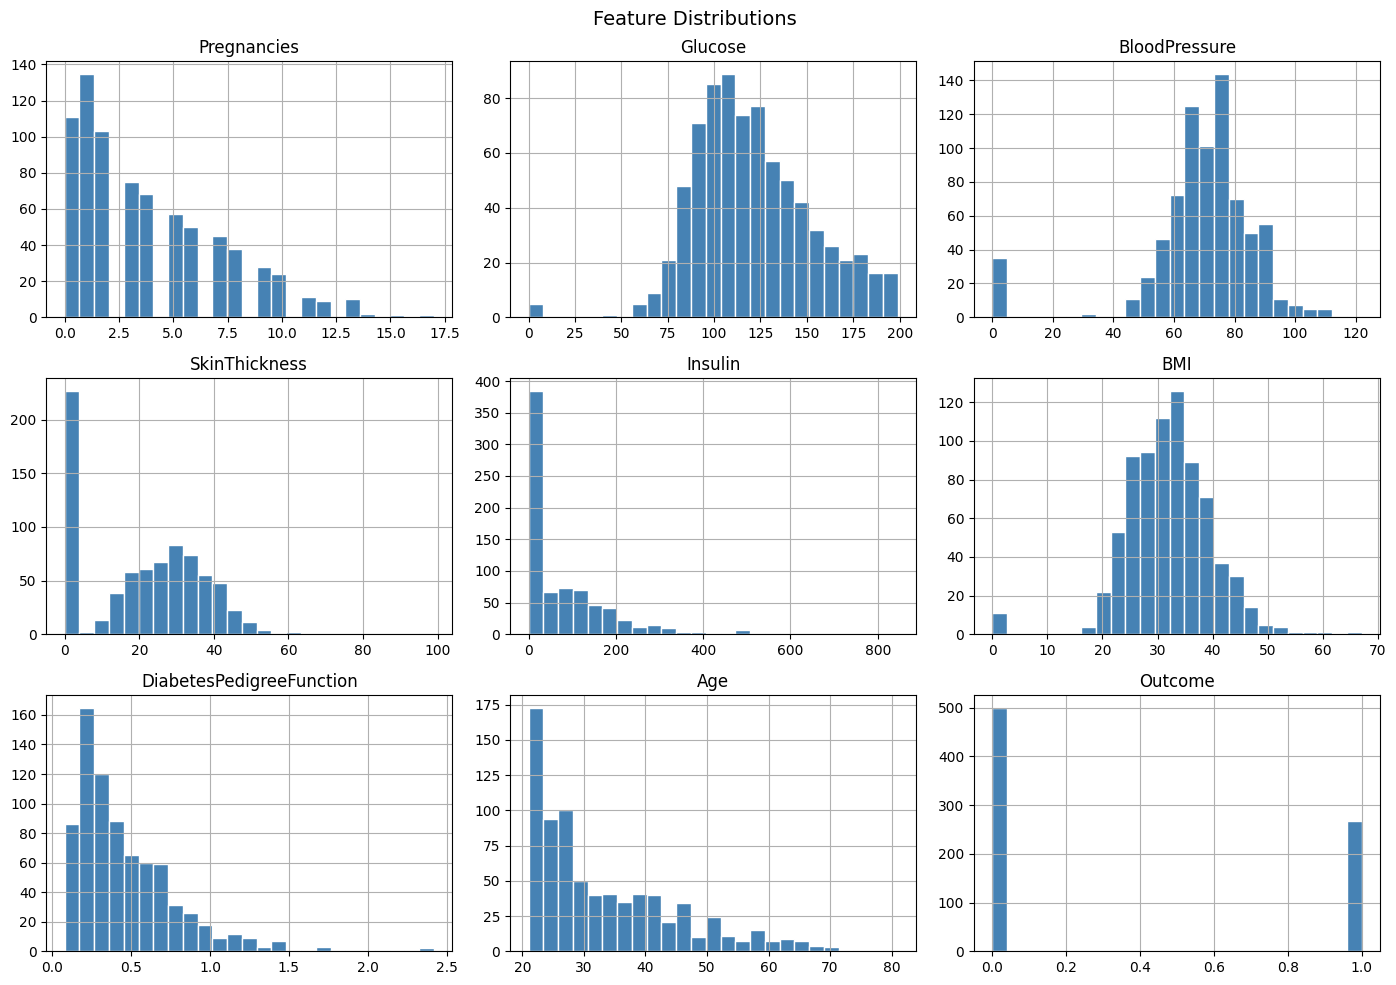

Glucose                  : 5 zeros → replaced with median 117.0
BloodPressure            : 35 zeros → replaced with median 72.0
SkinThickness            : 227 zeros → replaced with median 23.0
Insulin                  : 374 zeros → replaced with median 31.2
BMI                      : 11 zeros → replaced with median 32.0
Pregnancies                   : +0.376
Glucose                       : +1.209
BloodPressure                 : -0.054
SkinThickness                 : +0.029
Insulin                       : -0.133
BMI                           : +0.701
DiabetesPedigreeFunction      : +0.245
Age                           : +0.138
              precision    recall  f1-score   support

     Healthy       0.75      0.82      0.78       100
    Diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



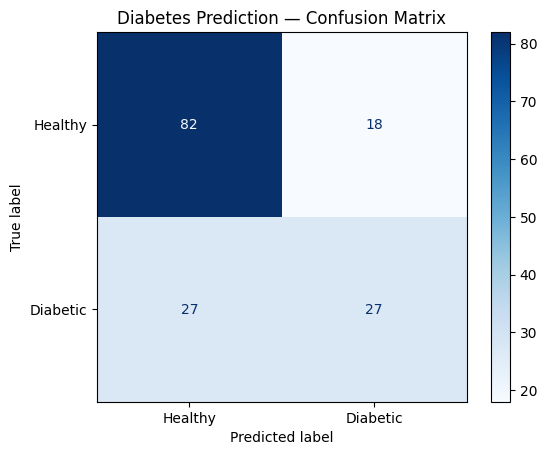

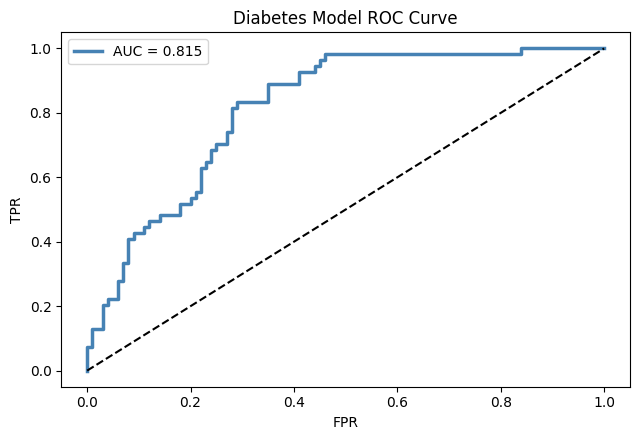

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Prediction : Diabetic
Probability : 73.4% chance of having diabetes


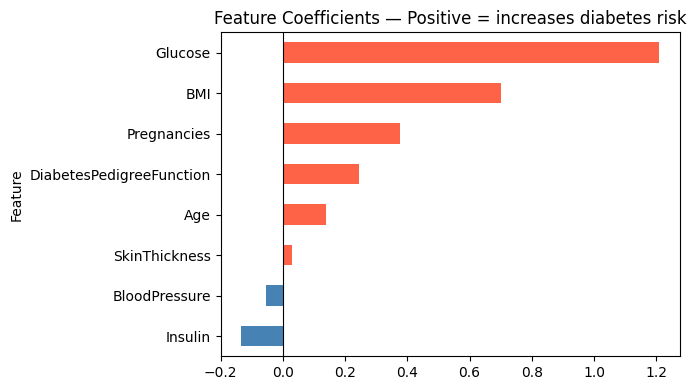

In [ ]:
# ■■ Load and Explore ■■
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
ConfusionMatrixDisplay, roc_auc_score, roc_curve)

# Download the dataset if not already present
!test -f diabetes.csv || wget https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv

df = pd.read_csv('diabetes.csv') # https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
print(df.shape) # (768, 9)
print(df['Outcome'].value_counts()) # 500 healthy, 268 diabetic
print(df.describe().round(2)) # stats: mean/std/min/max
# Distribution of each feature vs outcome
df.hist(bins=25, figsize=(14,10), color='steelblue', edgecolor='white')
plt.suptitle('Feature Distributions', fontsize=14); plt.tight_layout(); plt.show()
# ■■ Handle Missing Values ■■
# Glucose, BMI, etc. cannot be 0 — these are missing values disguised as zeros
fix_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in fix_cols:
    n = (df[col] == 0).sum()
    df[col] = df[col].replace(0, df[col].median())
    print(f'{col:25s}: {n} zeros → replaced with median {df[col].median():.1f}')
    # ■■ Split, Scale, Train ■■
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.20, random_state=42, stratify=y # stratify keeps class ratio
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # fit on train, transform train
X_test = scaler.transform(X_test) # only transform test (no leakage!)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
# Print learned coefficient for each feature
for name, coef in zip(X.columns, model.coef_[0]):
    print(f'{name:30s}: {coef:+.3f}') # positive → increases diabetes risk
    # ■■ Evaluate ■■
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=['Healthy','Diabetic']))
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Healthy','Diabetic']).plot(cmap='Blues')
plt.title('Diabetes Prediction — Confusion Matrix'); plt.show()
# ROC + AUC
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(6.5, 4.5))
plt.plot(fpr, tpr, lw=2.5, color='steelblue', label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'k--'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Diabetes Model ROC Curve'); plt.legend(); plt.tight_layout(); plt.show()
# Expected: Accuracy ~78%, AUC ~0.84
# ■■ Predict New Patient + Coefficient Plot ■■
# Row: [Pregnancies, Glucose, BP, SkinThickness, Insulin, BMI, DPF, Age]
new_patient = np.array([[6, 148, 72, 35, 0, 33.6, 0.627, 50]])
new_scaled = scaler.transform(new_patient) # must use same scaler
pred = model.predict(new_scaled)[0]
prob = model.predict_proba(new_scaled)[0, 1]
print(f'Prediction : {'Diabetic' if pred==1 else 'Healthy'}')
print(f'Probability : {prob:.1%} chance of having diabetes')
# BONUS: Plot coefficients as a horizontal bar chart
import pandas as pd
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coef_df = coef_df.sort_values('Coefficient')
coef_df.plot(kind='barh', x='Feature', y='Coefficient',
color=['tomato' if c > 0 else 'steelblue' for c in coef_df['Coefficient']],
legend=False, figsize=(7, 4))
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Coefficients — Positive = increases diabetes risk')
plt.tight_layout(); plt.show()

**DAY 9** Classify Mushrooms — Edible or Poisonous

--2026-06-17 13:10:11--  https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘mushrooms.csv’

mushrooms.csv           [ <=>                ] 364.95K  --.-KB/s    in 0.1s    

2026-06-17 13:10:11 (2.53 MB/s) - ‘mushrooms.csv’ saved [373704]

(8124, 23)
class
e    4208
p    3916
Name: count, dtype: int64
Train: 6499 rows | Test: 1625 rows
Decision Tree (depth=4) accuracy: 98.22%
|--- feature_8 <= 3.50
|   |--- feature_20 <= 3.50
|   |   |--- feature_19 <= 1.50
|   |   |   |--- class: 1
|   |   |--- feature_19 >  1.50
|   |   |   |--- feature_21 <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- feature_21 >  0.50
|   |   |   |   |--- class: 0
|   |--- feature_20 >  3.50
|   |   |--- feature_10 <= 2.00
|   |   |   

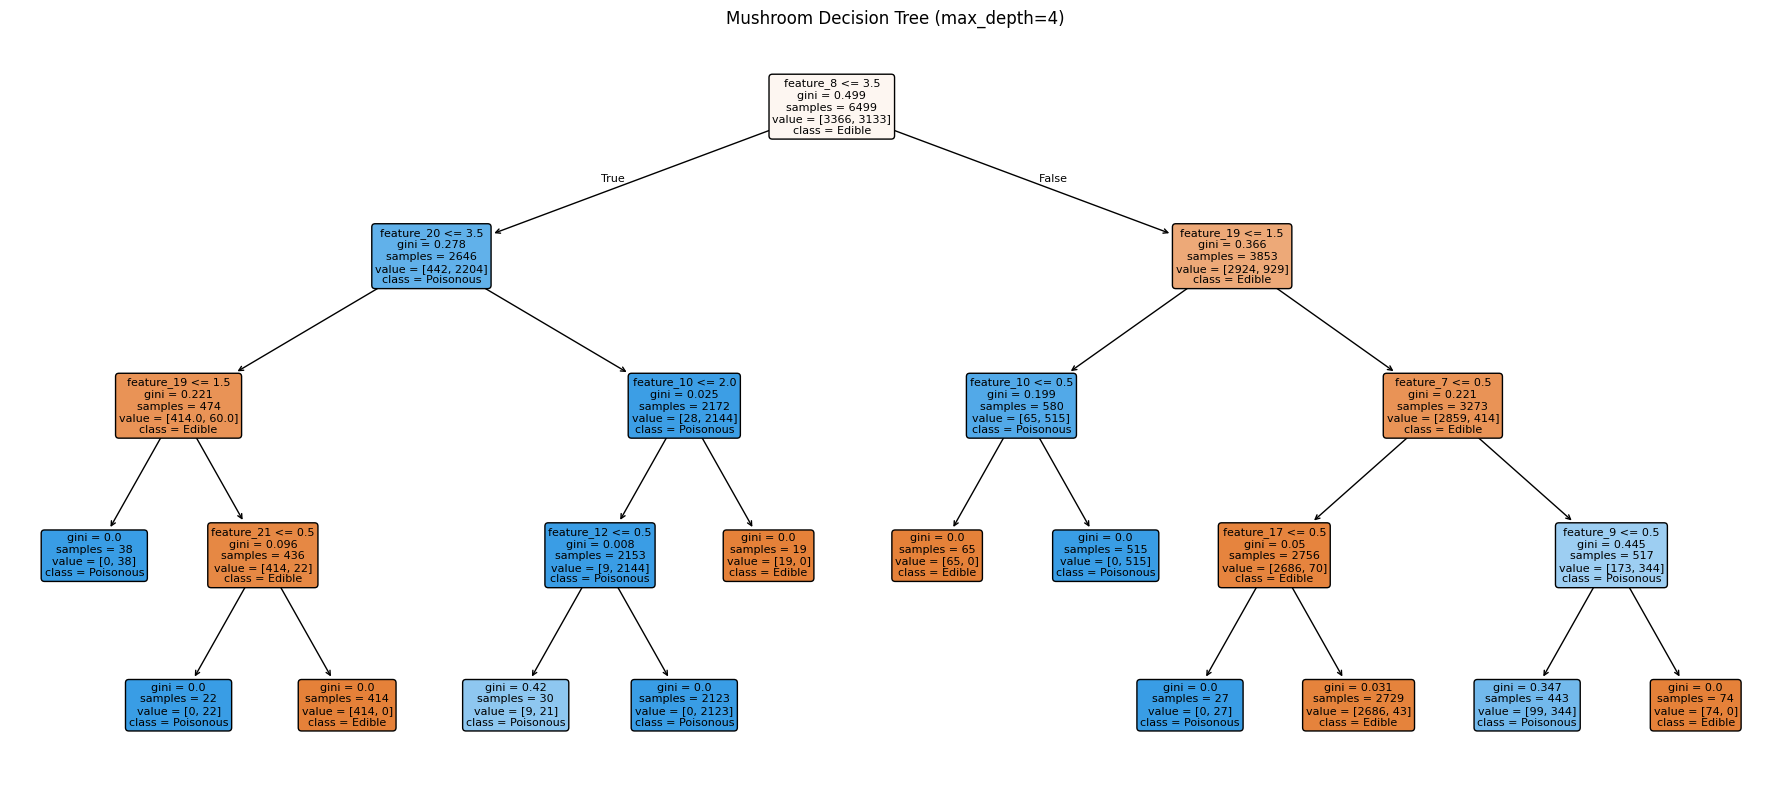

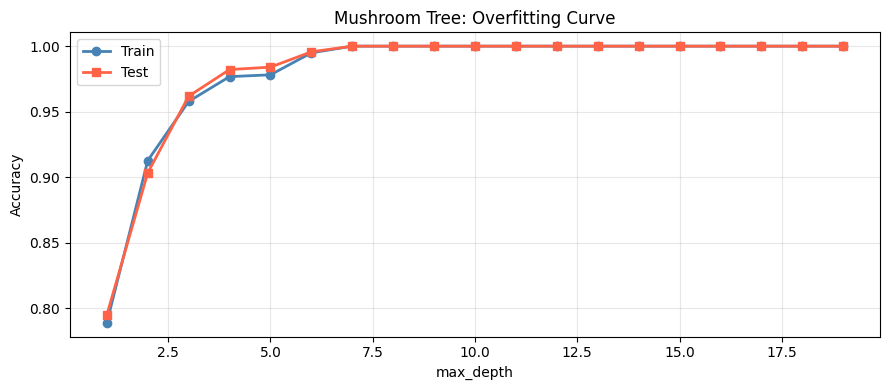

Best depth: 7, Test accuracy: 100.00%
Random Forest Test Accuracy: 100.00%
Random Forest OOB Accuracy: 100.00%
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

5-Fold CV: 88.54% ± 16.24%


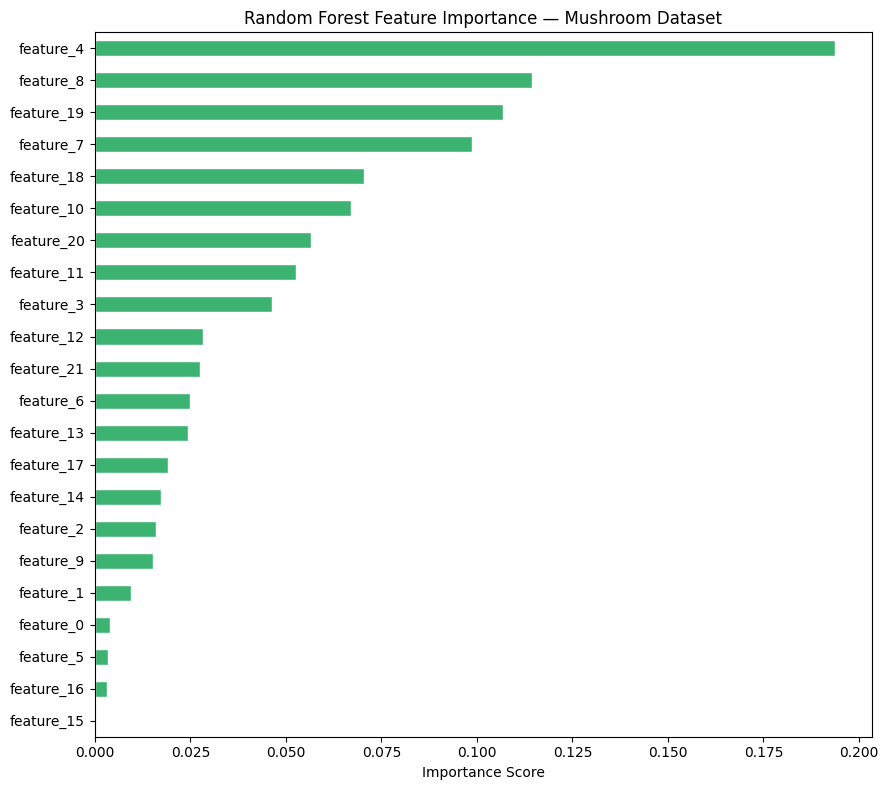


Accuracy WITHOUT odor feature: 100.00%
Accuracy WITH odor feature: 100.00%
Prediction : POISONOUS
Actual : POISONOUS
Confidence : 100.0%
Correct? : Yes!
✓ Pred: Poisonous | Conf: 100% | Actual: Poisonous
✓ Pred: Poisonous | Conf: 100% | Actual: Poisonous
✓ Pred: Edible    | Conf: 100% | Actual: Edible
✓ Pred: Poisonous | Conf: 100% | Actual: Poisonous
✓ Pred: Poisonous | Conf: 100% | Actual: Poisonous
✓ Pred: Edible    | Conf: 100% | Actual: Edible
✓ Pred: Edible    | Conf: 100% | Actual: Edible
✓ Pred: Edible    | Conf: 100% | Actual: Edible
✓ Pred: Edible    | Conf: 100% | Actual: Edible
✓ Pred: Poisonous | Conf: 100% | Actual: Poisonous


In [ ]:
# ■■ Load and Encode ■■
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Download the dataset if it's not present
import os
if not os.path.exists('mushrooms.csv'):
    !wget https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data -O mushrooms.csv

df = pd.read_csv('mushrooms.csv') # kaggle: 'mushroom classification'
# The downloaded dataset does not have headers, so we need to add them or handle it without
# For simplicity, let's load it and assume the first column is 'class' for now
# In a real scenario, you would need to define column names.

# For the mushroom dataset from UCI, the 'class' column is the first one.
# The column names are not in the CSV, so we'll need to handle it accordingly.
# Let's assume the dataset from UCI is comma-separated without header.
# The 'class' column is the first column in this dataset.

# Let's reload with proper column names if available, or use integers.
# Based on common usage of this dataset, let's add dummy column names
# and then assign the first column as 'class'.
# There are 23 columns. The first one is the class.
column_names = ['class'] + [f'feature_{i}' for i in range(22)]
df = pd.read_csv('mushrooms.csv', header=None, names=column_names)

print(df.shape) # (8124, 23)
print(df['class'].value_counts()) # p=4208 poisonous, e=3916 edible

# Encode every column: text → integer
# LabelEncoder: 'e'→0, 'p'→1 (and similarly for all features)
le = LabelEncoder()
df_enc = df.copy()
for col in df_enc.columns:
    df_enc[col] = le.fit_transform(df_enc[col])
X = df_enc.drop('class', axis=1) # 22 features
y = df_enc['class'] # 0=edible, 1=poisonous
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train)} rows | Test: {len(X_test)} rows')
# ■■ Decision Tree: Train + Visualise ■■
# ■■ Shallow tree (depth=4) — interpretable ■■
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
print(f'Decision Tree (depth=4) accuracy: {dt.score(X_test, y_test):.2%}')
# Text rules — read them like an if-else chain
print(export_text(dt, feature_names=list(X.columns)))
# ■■ Find the single most important feature ■■
imp = pd.Series(dt.feature_importances_, index=X.columns)
top = imp.idxmax()
print(f'Most important feature: {top} (importance={imp[top]:.3f})')
# Hint: 'odor' almost always comes first!
# odor=none → almost certainly edible. Smell saves lives.
# ■■ Visual tree ■■
plt.figure(figsize=(18, 8))
plot_tree(dt, feature_names=X.columns, class_names=['Edible','Poisonous'],
filled=True, rounded=True, fontsize=8) # Changed fontsize to an integer
plt.title('Mushroom Decision Tree (max_depth=4)'); plt.tight_layout()
plt.savefig('mushroom_tree.png', dpi=150, bbox_inches='tight')
plt.show()
# ■■ Depth Sweep ■■
train_acc, test_acc = [], []
for d in range(1, 20):
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_acc.append(tree.score(X_train, y_train))
    test_acc.append(tree.score(X_test, y_test))
plt.figure(figsize=(9, 4))
plt.plot(range(1,20), train_acc, 'o-', lw=2, label='Train', color='steelblue')
plt.plot(range(1,20), test_acc, 's-', lw=2, label='Test', color='tomato')
plt.xlabel('max_depth'); plt.ylabel('Accuracy')
plt.title('Mushroom Tree: Overfitting Curve')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
best = range(1,20)[test_acc.index(max(test_acc))]
print(f'Best depth: {best}, Test accuracy: {max(test_acc):.2%}')
# ■■ Random Forest: Full Evaluation + Ablation Test ■■
rf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(f'Random Forest Test Accuracy: {rf.score(X_test, y_test):.2%}')
print(f'Random Forest OOB Accuracy: {rf.oob_score_:.2%}')
print(classification_report(y_test, rf.predict(X_test), target_names=['Edible','Poisonous']))
# Cross-validation for robustness check (5 different splits)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print(f'5-Fold CV: {cv_scores.mean():.2%} ± {cv_scores.std():.2%}')
# Feature importance bar chart
rf_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
rf_imp.plot(kind='barh', figsize=(9, 8), color='mediumseagreen', edgecolor='white')
plt.title('Random Forest Feature Importance — Mushroom Dataset', fontsize=12)
plt.xlabel('Importance Score'); plt.tight_layout(); plt.show()
# EXPERIMENT: Remove 'odor' and retrain — does accuracy drop dramatically?
X_no_odor = X.drop(columns=['feature_8']) # Changed 'odor' to 'feature_8'
X_tr2, X_te2, ytr, yte = train_test_split(X_no_odor, y, test_size=0.2, random_state=42)
rf2 = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_tr2, ytr)
print(f'\nAccuracy WITHOUT odor feature: {rf2.score(X_te2, yte):.2%}')
print(f'Accuracy WITH odor feature: {rf.score(X_test, y_test):.2%}')
# ■■ Predict New Mushrooms ■■
# Grab a single mushroom from the test set to predict
sample_index = 0
sample = X_test.iloc[[sample_index]]
true_label = y_test.iloc[sample_index]
pred = rf.predict(sample)[0]
prob = rf.predict_proba(sample)[0]
label = 'Edible' if pred == 0 else 'POISONOUS'
actual = 'Edible' if true_label == 0 else 'POISONOUS'
print(f'Prediction : {label}')
print(f'Actual : {actual}')
print(f'Confidence : {max(prob):.1%}')
print(f'Correct? : {'Yes!' if pred == true_label else 'No...'}')
# Try multiple samples
for i in range(10):
    samp = X_test.iloc[[i]]
    pred = rf.predict(samp)[0]
    conf = max(rf.predict_proba(samp)[0])
    true = y_test.iloc[i]
    mark = '✓' if pred == true else '✗'
    predicted_label_str = 'Edible' if pred == 0 else 'Poisonous'
    actual_label_str = 'Edible' if true == 0 else 'Poisonous'
    print(f'{mark} Pred: {predicted_label_str:9s} | Conf: {conf:.0%} | Actual: {actual_label_str}')

**DAY 10** MNIST Handwritten Digit Recognition

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Full dataset: (70000, 784)
Train: (8000, 784) Test: (2000, 784)
Test Accuracy: 90.50%
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       200
           1       0.87      0.99      0.93       225
           2       0.91      0.84      0.87       198
           3       0.89      0.92      0.90       206
           4       0.93      0.85      0.89       196
           5       0.91      0.89      0.90       173
           6       0.95      0.95      0.95       203
           7       0.92      0.87      0.89       214
           8       0.93      0.83      0.88       189
           9       0.85      0.91      0.88       196

    accuracy                           0.91      2000
   macro avg       0.91      0.90      0.90      2000
weighted avg       0.91      0.91      0.90      2000



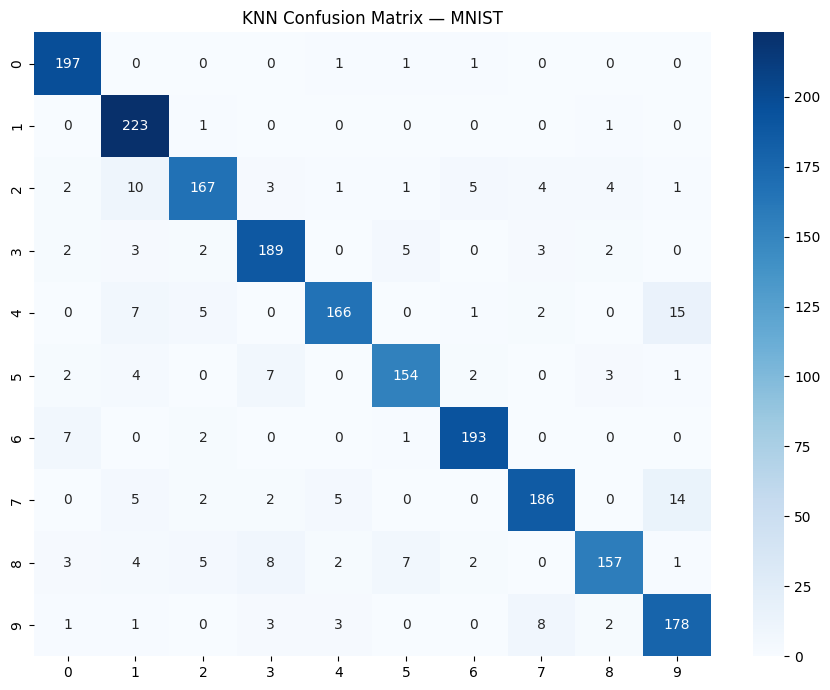

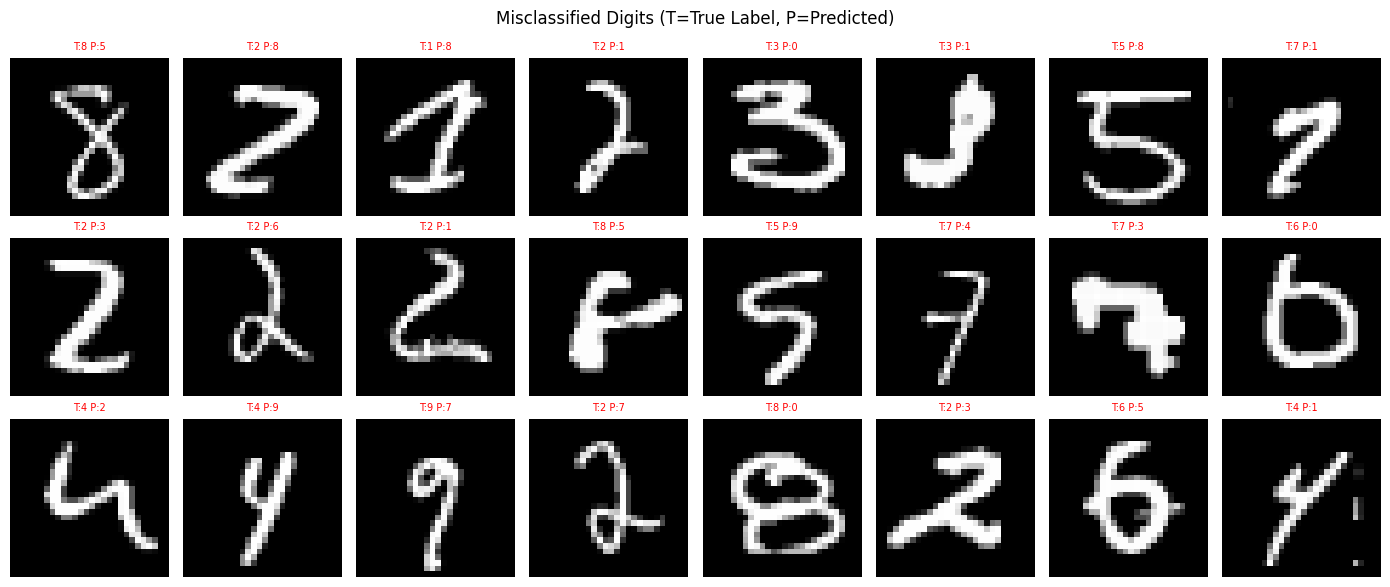

K=9 Accuracy=90.70%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
# from sklearn.datasets import fetch_openml # Commenting out problematic import
import tensorflow as tf # Import TensorFlow
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# ■■ Load MNIST using tf.keras.datasets (more robust) ■■■■■■■■■■■
print('Loading MNIST dataset...')
(X_train_full, y_train_full), (X_test_full, y_test_full) = tf.keras.datasets.mnist.load_data()

# Combine train and test for consistent processing as per original fetch_openml output structure
X = np.concatenate((X_train_full, X_test_full), axis=0)
y = np.concatenate((y_train_full, y_test_full), axis=0)

# Flatten the images from 28x28 to 784 features
X = X.reshape(X.shape[0], -1)

print(f'Full dataset: {X.shape}') # (70000, 784)
# Ensure y is integer type, as fetch_openml does
y = y.astype(int)
# ■■ Use 10,000 samples (full set takes ~10 min to predict) ■■■■
X, y = X[:10000], y[:10000]
X_train,X_test,y_train,y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape} Test: {X_test.shape}')
# ■■ Scale pixels 0-255 to standardised values ■■■■■■■■■■■■■■■■■
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(X_train.astype(float))
Xte_s = scaler.transform(X_test.astype(float))
# ■■ Train KNN (ball_tree is faster for high-dim data) ■■■■■■■■■
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean',
algorithm='ball_tree', n_jobs=-1)
knn.fit(Xtr_s, y_train)
# ■■ Evaluate ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
y_pred = knn.predict(Xte_s)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')
print(classification_report(y_test, y_pred))
# ■■ Confusion matrix ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=range(10), yticklabels=range(10))
plt.title('KNN Confusion Matrix — MNIST'); plt.tight_layout(); plt.show()
# ■■ Show misclassified images ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
wrong = np.where(y_pred != y_test)[0]
fig, axes = plt.subplots(3,8,figsize=(14,6))
for i,ax in enumerate(axes.flat):
  if i < len(wrong):
    ax.imshow(X_test[wrong[i]].reshape(28,28), cmap='gray')
    ax.set_title(f'T:{y_test[wrong[i]]} P:{y_pred[wrong[i]]}',
    color='red', fontsize=7)
  ax.axis('off')
plt.suptitle('Misclassified Digits (T=True Label, P=Predicted)')
plt.tight_layout(); plt.show()
# ■■ Compare K values ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
for k in [1,3,5,7,9]:
  kk = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
  kk.fit(Xtr_s, y_train)
print(f'K={k} Accuracy={accuracy_score(y_test, kk.predict(Xte_s))*100:.2f}%')

**DAY 11**Goal: Find natural customer groups — without any pre-defined
labels — so the marketing team can target each group differently.

   CustomerID  Gender  Age  Income  SpendingScore
0           1    Male   57      36             53
1           2  Female   35      44             68
2           3  Female   60      55             23
3           4  Female   61      60             54
4           5    Male   59      48             31
(200, 5)
CustomerID        int64
Gender           object
Age               int64
Income            int64
SpendingScore     int64
dtype: object
CustomerID       0
Gender           0
Age              0
Income           0
SpendingScore    0
dtype: int64
       CustomerID    Age  Income  SpendingScore
count       200.0  200.0   200.0          200.0
mean        100.5   43.3    45.7           48.8
std          57.9   15.5    16.1           19.4
min           1.0   17.0    11.0           -2.0
25%          50.8   28.0    32.8           32.0
50%         100.5   45.0    46.5           50.0
75%         150.2   58.0    58.0           64.0
max         200.0   72.0    87.0           93.0


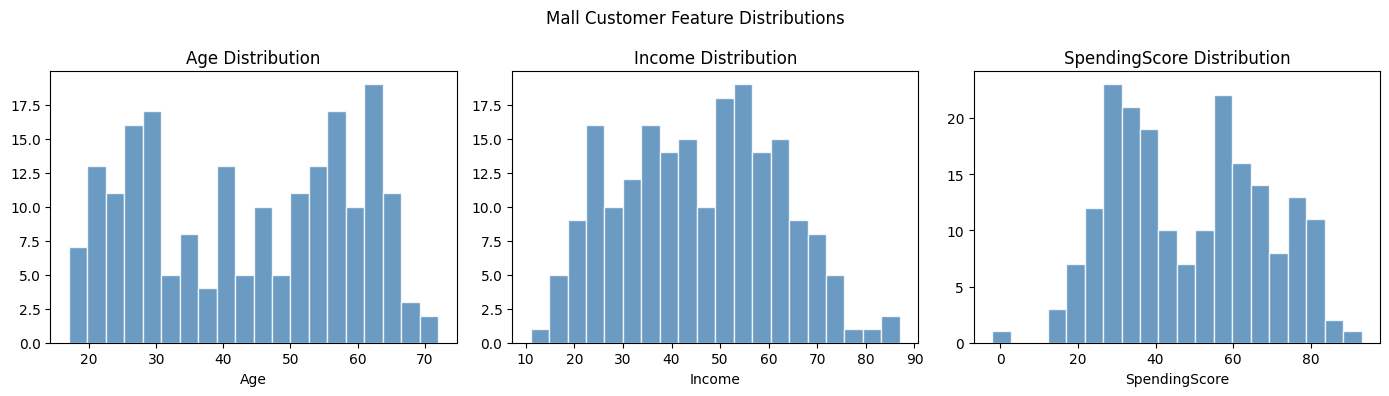

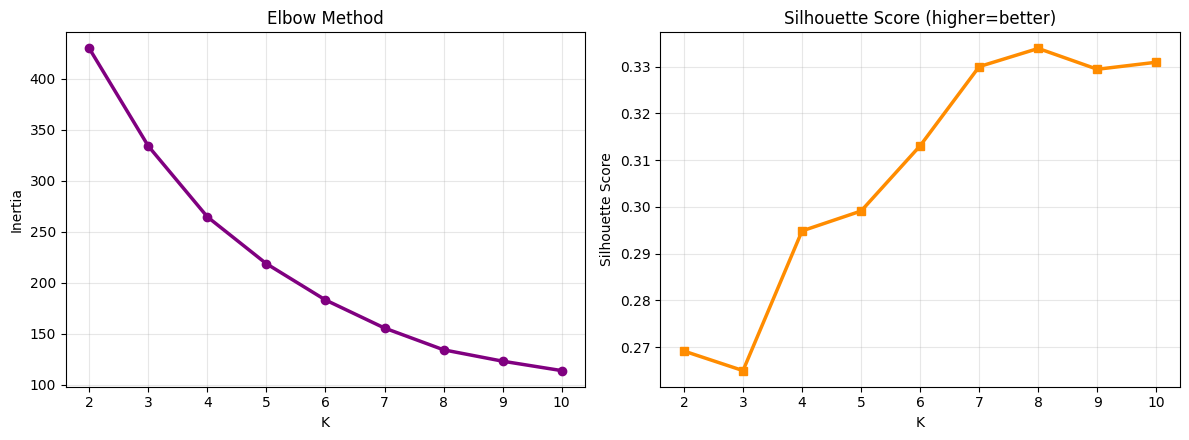

          Age             Income             SpendingScore            
         mean   std count   mean   std count          mean   std count
Cluster                                                               
0        56.0   6.6    32   56.8   8.6    32          66.2  10.4    32
1        26.3   5.8    39   51.1  14.2    39          66.7  11.5    39
2        28.9   7.2    44   33.4  11.5    44          38.7  11.4    44
3        53.2  11.3    44   59.8   8.5    44          29.2   9.1    44
4        54.4   8.3    41   29.8   7.2    41          49.9  18.4    41


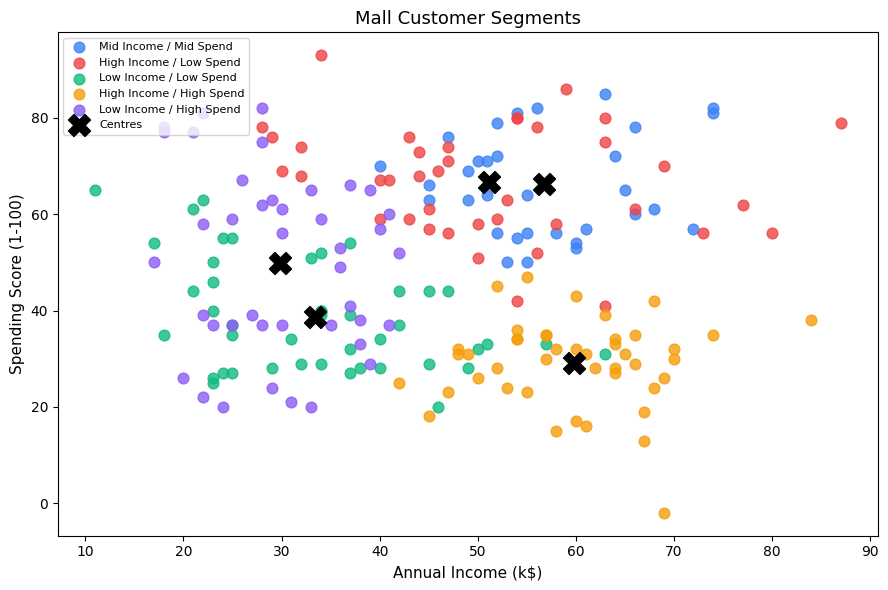

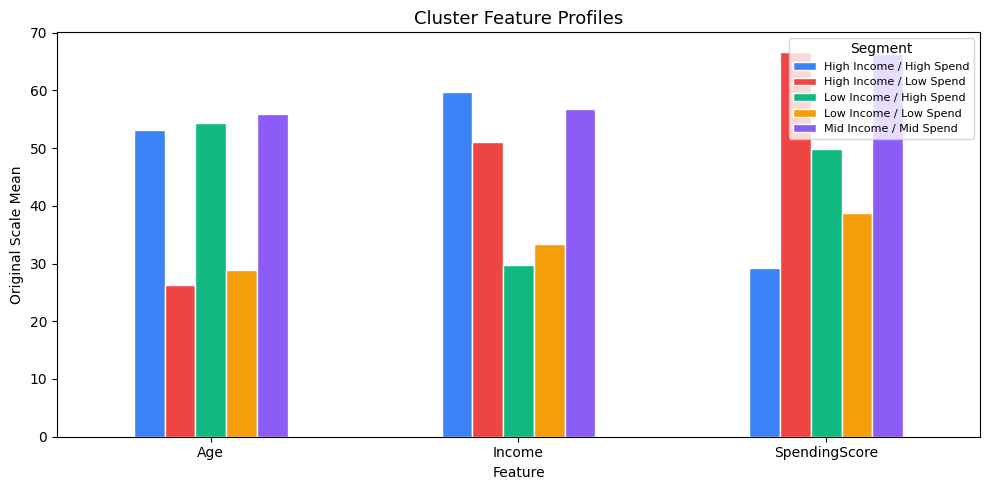


Marketing Strategy Recommendations:
High Income / High Spend: 44 customers
 → Loyalty programmes, premium brands, VIP events

High Income / Low Spend: 39 customers
 → Re-engagement campaigns, personalised offers

Low Income / High Spend: 41 customers
 → Flexible payment, budget promotions, discounts

Low Income / Low Spend: 44 customers
 → Value deals, essentials focus

Mid Income / Mid Spend: 32 customers
 → Broad marketing, seasonal promotions



In [ ]:
# ■■ Load & Explore ■■
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
# Dataset: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial
# df = pd.read_csv('Mall_Customers.csv') # Original line causing FileNotFoundError

# Generate synthetic data similar to Mall_Customers.csv
np.random.seed(42)
n_samples = 200

customer_ids = np.arange(1, n_samples + 1)
gender = np.random.choice(['Male', 'Female'], size=n_samples, p=[0.4, 0.6]) # Roughly 40/60 split

# Age distribution (e.g., young, middle, older groups)
age_dist_young = np.random.normal(25, 5, n_samples // 3)
age_dist_mid = np.random.normal(45, 8, n_samples // 3)
age_dist_old = np.random.normal(60, 6, n_samples - 2 * (n_samples // 3))
age = np.concatenate([age_dist_young, age_dist_mid, age_dist_old])
np.random.shuffle(age) # Shuffle to mix age groups
age = age[:n_samples].astype(int) # Ensure exact n_samples and integer ages

# Annual Income distribution
income_dist_low = np.random.normal(30, 8, n_samples // 3)
income_dist_mid1 = np.random.normal(60, 12, n_samples // 3)
income_dist_mid2 = np.random.normal(50, 10, n_samples - 2 * (n_samples // 3))
income = np.concatenate([income_dist_low, income_dist_mid1, income_dist_mid2])
np.random.shuffle(income)
income = income[:n_samples].astype(int)

# Spending Score distribution
spending_dist_high = np.random.normal(70, 10, n_samples // 3)
spending_dist_mid = np.random.normal(50, 15, n_samples // 3)
spending_dist_low = np.random.normal(30, 8, n_samples - 2 * (n_samples // 3))
spending_score = np.concatenate([spending_dist_high, spending_dist_mid, spending_dist_low])
np.random.shuffle(spending_score)
spending_score = spending_score[:n_samples].astype(int)

# Create DataFrame with names matching the original CSV's post-rename columns
df = pd.DataFrame({
    'CustomerID': customer_ids,
    'Gender': gender,
    'Age': age,
    'Income': income,
    'SpendingScore': spending_score
})

print(df.head())
print(df.shape) # (200, 5)
print(df.dtypes) # int64 and object columns
print(df.isnull().sum()) # Check: should be 0 missing values
print(df.describe().round(1)) # Stats overview
# The original line `df.columns = ['CustomerID','Gender','Age','Income','SpendingScore']` is now redundant
# as the DataFrame is created with these column names directly.

# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Age','Income','SpendingScore']):
  ax.hist(df[col], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
  ax.set_title(f'{col} Distribution'); ax.set_xlabel(col)
plt.suptitle('Mall Customer Feature Distributions'); plt.tight_layout(); plt.show()
# ■■ Elbow + Silhouette ■■
# Select features for clustering (drop ID and Gender for now)
features = ['Age', 'Income', 'SpendingScore']
X = df[features]
# Standardise: K-Means uses Euclidean distance — scale matters!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
inertias, sil_scores = [], []
K_range = range(2, 11)
for k in K_range:
  km = KMeans(n_clusters=k, n_init=10, random_state=42)
  km.fit(X_scaled)
  inertias.append(km.inertia_)
  sil_scores.append(silhouette_score(X_scaled, km.labels_))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(K_range, inertias, 'o-', color='purple', lw=2.5)
ax1.set_xlabel('K'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method'); ax1.grid(alpha=0.3)
ax2.plot(K_range, sil_scores, 's-', color='darkorange', lw=2.5)
ax2.set_xlabel('K'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score (higher=better)'); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()
# ■■ Fit K-Means + Profile Clusters ■■
best_k = 5 # Typical result for this dataset
km = KMeans(n_clusters=best_k, n_init=20, random_state=42)
df['Cluster'] = km.fit_predict(X_scaled)
# ■■ Cluster summary ■■
summary = df.groupby('Cluster')[features].agg(['mean','std','count'])
print(summary.round(1))
# ■■ Name the clusters based on their profiles ■■
cluster_labels = {
0: 'Mid Income / Mid Spend',
1: 'High Income / Low Spend',
2: 'Low Income / Low Spend',
3: 'High Income / High Spend',
4: 'Low Income / High Spend',
}
df['Segment'] = df['Cluster'].map(cluster_labels)
# ■■ Scatter plot: Income vs Spending, coloured by cluster ■■
palette = ['#3B82F6','#EF4444','#10B981','#F59E0B','#8B5CF6']
plt.figure(figsize=(9, 6))
for c in range(best_k):
  mask = df['Cluster'] == c
  plt.scatter(df[mask]['Income'], df[mask]['SpendingScore'],
    c=palette[c], s=60, alpha=0.8, label=cluster_labels[c])
centres_orig = scaler.inverse_transform(km.cluster_centers_)
plt.scatter(centres_orig[:,1], centres_orig[:,2], c='black',
s=250, marker='X', zorder=5, label='Centres')
plt.xlabel('Annual Income (k$)', fontsize=11)
plt.ylabel('Spending Score (1-100)', fontsize=11)
plt.title('Mall Customer Segments', fontsize=13)
plt.legend(loc='upper left', fontsize=8); plt.tight_layout(); plt.show()
# ■■ Profiles + Marketing Insights ■■
# ■■ Radar / bar chart of cluster profiles ■■
profile_means = df.groupby('Segment')[features].mean()
profile_means.T.plot(kind='bar', figsize=(10, 5),
color=palette[:best_k], edgecolor='white')
plt.title('Cluster Feature Profiles', fontsize=13)
plt.xlabel('Feature'); plt.ylabel('Original Scale Mean')
plt.legend(title='Segment', fontsize=8, loc='upper right')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()
# ■■ Marketing strategy per segment ■■
strategies = {
'High Income / High Spend' : '→ Loyalty programmes, premium brands, VIP events',
'High Income / Low Spend' : '→ Re-engagement campaigns, personalised offers',
'Low Income / High Spend' : '→ Flexible payment, budget promotions, discounts',
'Low Income / Low Spend' : '→ Value deals, essentials focus',
'Mid Income / Mid Spend' : '→ Broad marketing, seasonal promotions',
}
print('\nMarketing Strategy Recommendations:')
print('=' * 60)
for seg, strat in strategies.items():
  count = len(df[df['Segment']==seg])
  print(f'{seg}: {count} customers')
  print(f' {strat}\n')

**DAY 12**Build a complete model selection pipeline: load data, preprocess, train 4 models, evaluate with cross-validation, tune
hyperparameters, and produce a final comparison report. We use the Pima Indians Diabetes dataset as the
benchmark.

Dataset: 768 rows, 8 features
Class balance: {0: 500, 1: 268}
              Model  Accuracy     F1  Roc_Auc  Precision  Recall  Time(s)
Logistic Regression    0.7708 0.7320   0.8372     0.7602  0.7219     0.21
      Random Forest    0.7577 0.7236   0.8235     0.7367  0.7170     1.31
                KNN    0.7435 0.7026   0.7912     0.7206  0.6948     0.13
      Decision Tree    0.7082 0.6682   0.7516     0.6851  0.6719     0.19
Best params : {'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 50}
Best CV acc : 0.7759

Default RF accuracy: 0.7577 ± 0.0266
Tuned RF accuracy: 0.7759 ± 0.0367


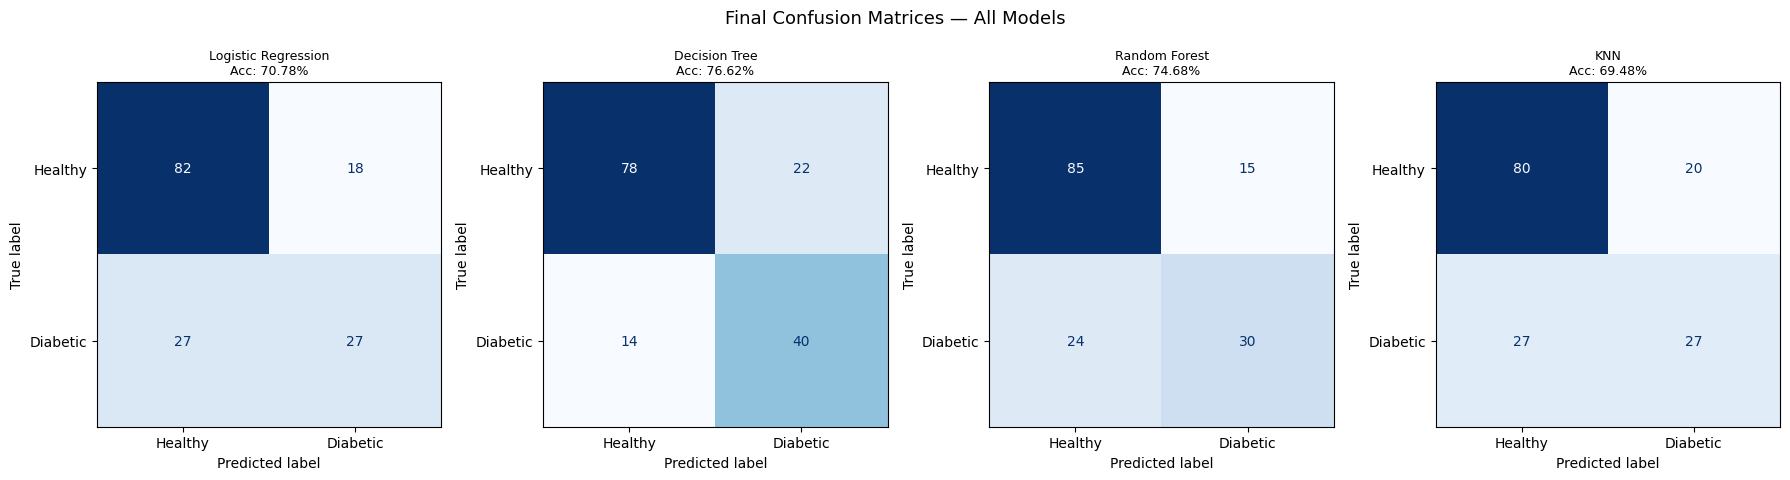


=== FINAL REPORT: Random Forest (Tuned) ===
              precision    recall  f1-score   support

     Healthy       0.78      0.85      0.81       100
    Diabetic       0.67      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154



In [ ]:
# ■■ Load and Clean ■■
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import time, warnings; warnings.filterwarnings('ignore')

# Check if 'diabetes.csv' exists, if not, download it
import os
if not os.path.exists('diabetes.csv'):
    # Using wget to download the file from a common public repository
    !wget https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv

df = pd.read_csv('diabetes.csv')
for col in ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']:
  df[col] = df[col].replace(0, df[col].median())
X = df.drop('Outcome', axis=1)
y = df['Outcome']
print(f'Dataset: {X.shape[0]} rows, {X.shape[1]} features')
print(f'Class balance: {y.value_counts().to_dict()}')
# Output: {0: 500, 1: 268} — slightly imbalanced
# ■■ Cross-Validation Leaderboard ■■
# Models — LR and KNN need scaling; trees don't (Pipeline handles this cleanly)
models = {
    'Logistic Regression': Pipeline([('sc',StandardScaler()),
('m',LogisticRegression(max_iter=1000,random_state=42))]),
'Decision Tree' : DecisionTreeClassifier(max_depth=5, random_state=42),
'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
'KNN' : Pipeline([('sc',StandardScaler()),
('m',KNeighborsClassifier(n_neighbors=7))]),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metrics = ['accuracy','f1_macro','roc_auc','precision_macro','recall_macro']
records = []
for name, model in models.items():
  t0 = time.time()
  res = cross_validate(model, X, y, cv=cv, scoring=metrics)
  elapsed = time.time()-t0
  row = {'Model': name, 'Time(s)': round(elapsed,2)}
  for m in metrics:
    row[m.replace('_macro','').title()] = round(res[f'test_{m}'].mean(), 4)
    row[f'{m.replace('_macro','').title()}_std'] = round(res[f'test_{m}'].std(), 4)
  records.append(row)
leaderboard = pd.DataFrame(records).sort_values('Accuracy', ascending=False)
print(leaderboard[['Model','Accuracy','F1','Roc_Auc','Precision','Recall','Time(s)']].to_string(index=False))
# ■■ GridSearch Tuning ■■
# From the leaderboard, suppose Random Forest wins
# Tune its key hyperparameters
param_grid = {
    'n_estimators' : [50, 100, 200],
'max_depth' : [None, 5, 10],
'min_samples_leaf': [1, 3, 5],
}
# 3×3×3 = 27 combos × 5-fold = 135 fits — runs in ~1 minute
gs = GridSearchCV(
RandomForestClassifier(random_state=42),
param_grid, cv=cv, scoring='accuracy',
n_jobs=-1, verbose=0
)
gs.fit(X, y)
print(f'Best params : {gs.best_params_}')
print(f'Best CV acc : {gs.best_score_:.4f}')
# Compare tuned vs default
default_rf = RandomForestClassifier(n_estimators=100, random_state=42)
default_scores = cross_val_score(default_rf, X, y, cv=cv, scoring='accuracy')
tuned_scores = cross_val_score(gs.best_estimator_, X, y, cv=cv, scoring='accuracy')
print(f'\nDefault RF accuracy: {default_scores.mean():.4f} ± {default_scores.std():.4f}')
print(f'Tuned RF accuracy: {tuned_scores.mean():.4f} ± {tuned_scores.std():.4f}')
# ■■ Final Evaluation Dashboard ■■
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# One final hold-out test — we only do this ONCE
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.20, random_state=42, stratify=y)
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
Final_models = {
'Logistic Regression': Pipeline([('sc',StandardScaler()),('m',LogisticRegression(max_iter=1000))]),
'Decision Tree' : DecisionTreeClassifier(max_depth=5, random_state=42),
'Random Forest' : gs.best_estimator_, # Tuned version
'KNN' : Pipeline([('sc',StandardScaler()),('m',KNeighborsClassifier(n_neighbors=7))]),
}
final_results = []
for ax, (name, model) in zip(axes, Final_models.items()):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  cm = confusion_matrix(y_test, y_pred)
  ConfusionMatrixDisplay(cm, display_labels=['Healthy','Diabetic']).plot(
  ax=ax, cmap='Blues', colorbar=False)
  ax.set_title(f'{name}\nAcc: {acc:.2%}', fontsize=9)
  final_results.append({'Model':name, 'Test Accuracy':f'{acc:.2%}'})
plt.suptitle('Final Confusion Matrices — All Models', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()
# Final report for best model
best_model = Final_models['Random Forest']
print('\n=== FINAL REPORT: Random Forest (Tuned) ===')
print(classification_report(y_test, best_model.predict(X_test),
target_names=['Healthy','Diabetic']))

**DAY 13**
Neural Networks

MNIST Classifier: Target 97%+


Build, train, and evaluate a neural network on the full MNIST dataset. Visualise predictions, inspect the
confusion matrix, examine misclassified digits, and experiment with different architectures to understand how
design choices affect accuracy.

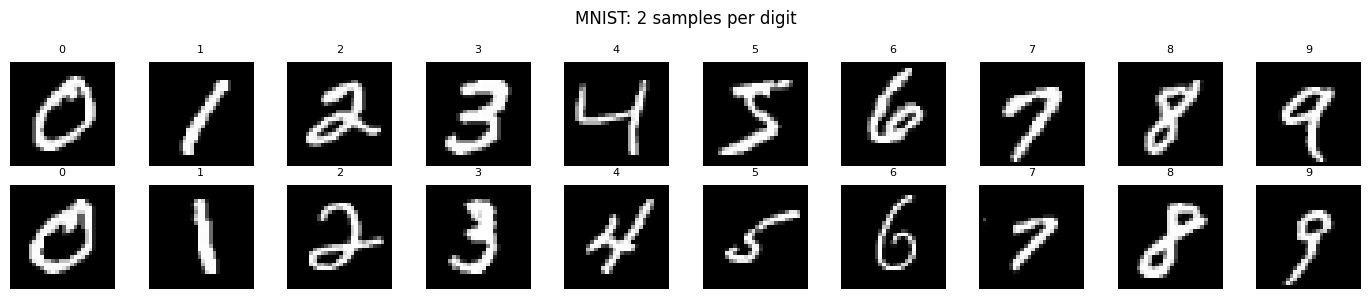

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8781 - loss: 0.4065 - val_accuracy: 0.9648 - val_loss: 0.1211
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9494 - loss: 0.1703 - val_accuracy: 0.9707 - val_loss: 0.0954
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9619 - loss: 0.1303 - val_accuracy: 0.9777 - val_loss: 0.0788
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9674 - loss: 0.1072 - val_accuracy: 0.9793 - val_loss: 0.0755
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9723 - loss: 0.0913 - val_accuracy: 0.9792 - val_loss: 0.0721
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9751 - loss: 0.0786 - val_accuracy: 0.9833 - val_loss: 0.0584
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9788 - loss: 0.0690 - val_accuracy: 0.9810 - val_loss: 0.0619
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9796 - loss: 0.0643 - val_accura

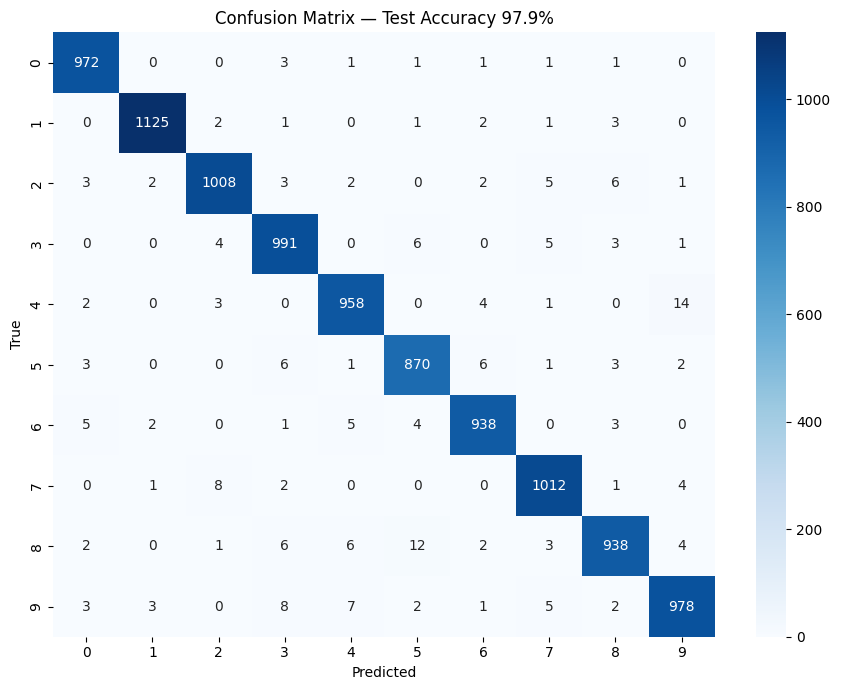

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.97      0.98      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.96      0.97       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

Misclassified: 210 out of 10000


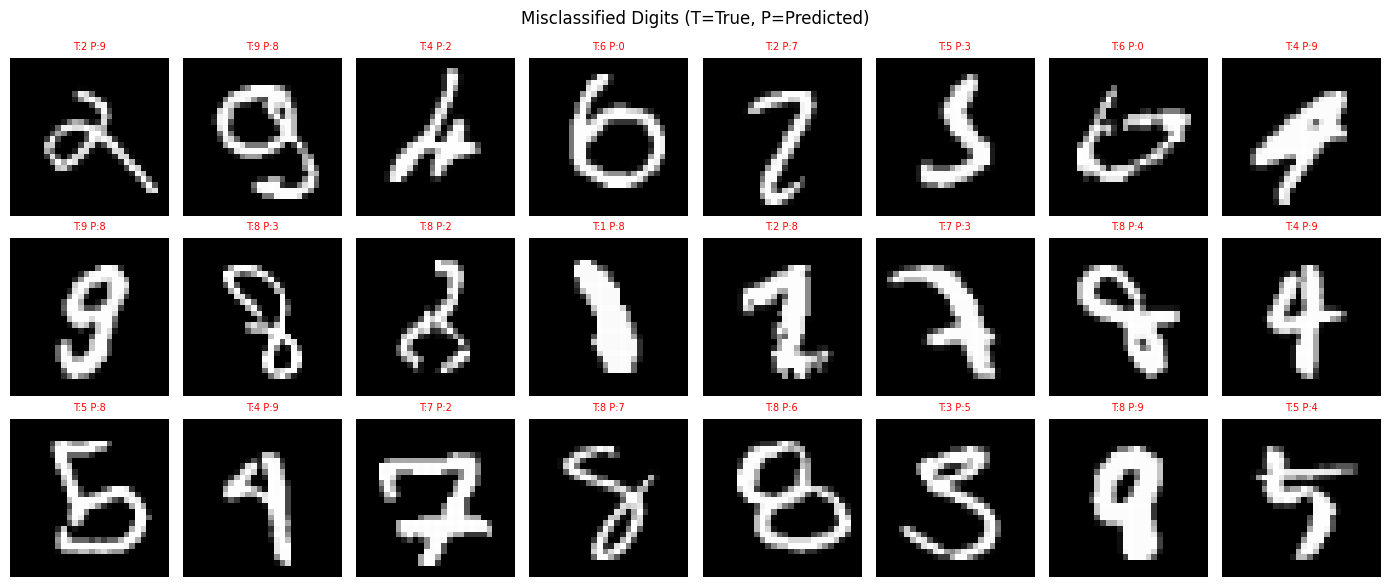

Large / moderate dropout            Accuracy: 98.03%


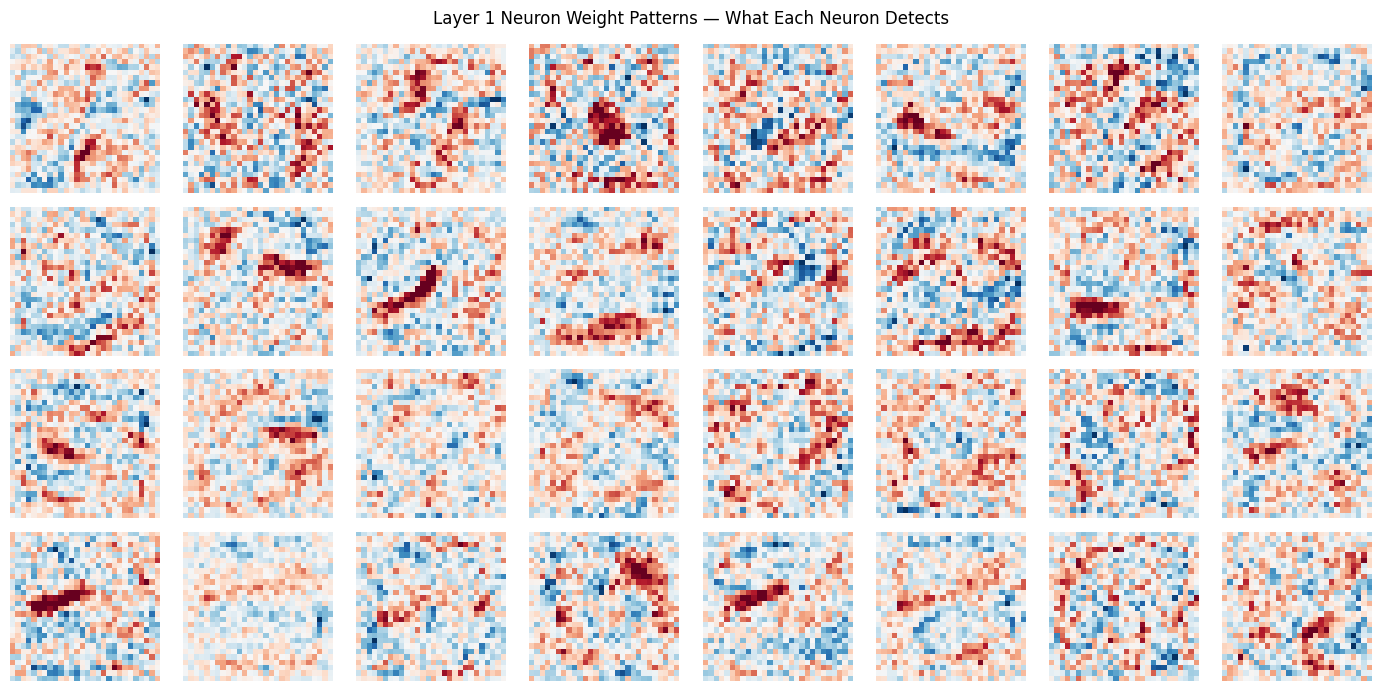

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report
# ■■ Load and preprocess MNIST ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test = X_test.reshape(-1, 784).astype('float32') / 255.0
# ■■ Visualise a sample of training digits ■■■■■■■■■■■■■■■■■■■■■
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for d in range(10):
  for r, offset in enumerate([0, 1]):
    idx = np.where(y_train == d)[0][offset]
    axes[r, d].imshow(X_train[idx].reshape(28,28), cmap='gray')
    axes[r, d].set_title(str(d), fontsize=8); axes[r, d].axis('off')
plt.suptitle('MNIST: 2 samples per digit'); plt.tight_layout(); plt.show()
# ■■ Build model as a reusable function ■■■■■■■■■■■■■■■■■■■■■■■
def make_model(h1=256, h2=128, drop=0.3):
  m = keras.Sequential([
  keras.Input(shape=(784,)),
  layers.Dense(h1, activation='relu'),
  layers.Dropout(drop),
  layers.Dense(h2, activation='relu'),
                       layers.Dropout(drop),
  layers.Dense(10, activation='softmax'),
  ])
  m.compile(optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])
  return m
model = make_model()
model.summary()
# ■■ Train ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
history = model.fit(
X_train, y_train, epochs=30, batch_size=128,
validation_split=0.1,
callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
verbose=1)
# ■■ Evaluate ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy: {acc*100:.2f}%')
# ■■ Confusion matrix ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=range(10), yticklabels=range(10))
plt.title(f'Confusion Matrix — Test Accuracy {acc*100:.1f}%')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()
# Diagonal = correctly classified. Off-diagonal = confused pairs.
# Common confusions: 4 vs 9, 3 vs 8, 5 vs 6
print(classification_report(y_test, y_pred))
# ■■ Show misclassified images ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
wrong = np.where(y_pred != y_test)[0]
print(f'Misclassified: {len(wrong)} out of {len(y_test)}')
fig, axes = plt.subplots(3, 8, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
  if i < len(wrong):
    idx = wrong[i]
    ax.imshow(X_test[idx].reshape(28,28), cmap='gray')
    ax.set_title(f'T:{y_test[idx]} P:{y_pred[idx]}',
    color='red', fontsize=7)
  ax.axis('off')
plt.suptitle('Misclassified Digits (T=True, P=Predicted)')
plt.tight_layout(); plt.show()
# ■■ Architecture comparison ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
configs = [
(64, 32, 0.0, 'Small / no dropout'),
(128, 64, 0.2, 'Medium / light dropout'),
(256, 128, 0.3, 'Large / moderate dropout'),
]
for h1, h2, dr, label in configs:
  m = make_model(h1, h2, dr)
  m.fit(X_train, y_train, epochs=15, batch_size=128,
    validation_split=0.1, verbose=0,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)])
_, a = m.evaluate(X_test, y_test, verbose=0)
print(f'{label:35s} Accuracy: {a*100:.2f}%')
# ■■ Each Layer 1 neuron has 784 weights (one per pixel) ■■■■■■■■
# Reshape to 28x28 to see which pixel patterns each neuron responds to
weights = model.layers[0].get_weights()[0] # shape: (784, 256)
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
  w = weights[:, i].reshape(28, 28)
  ax.imshow(w, cmap='RdBu', vmin=-w.max(), vmax=w.max())
  ax.axis('off')
plt.suptitle('Layer 1 Neuron Weight Patterns — What Each Neuron Detects')
plt.tight_layout(); plt.show()
# Blue = neuron activated strongly by bright pixel here
# Red = neuron suppressed by bright pixel here

**daY 14**
Feature Engineering & Data Preprocessing


Clean a messy real dataset

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
np.random.seed(42)
n = 500
# Generate synthetic HR data with intentional problems
df = pd.DataFrame({
'age': np.random.randint(22, 60, n).astype(float),
'salary': np.random.randint(25000, 120000, n).astype(float),
'dept': np.random.choice(['Eng','Sales','HR','Finance'], n),
'education': np.random.choice(['HS','BSc','MSc','PhD'], n),
'years_exp': np.random.randint(0, 35, n).astype(float),
'left_job': np.random.randint(0, 2, n), # target: 1=left, 0=stayed
})
# Inject missing values (~12% each column)
for col in ['age', 'salary', 'dept']:
    df.loc[df.sample(frac=0.12).index, col] = np.nan
# Inject outliers
df.loc[0, 'salary'] = 999999 # extreme outlier
df.loc[1, 'age'] = 150 # impossible age
print('Shape:', df.shape)
print(df.isnull().sum())
# Baseline: just drop rows with missing values — very naive
df_base = df.dropna()
X_base = pd.get_dummies(df_base.drop('left_job', axis=1))
y_base = df_base['left_job']
X_tr, X_te, y_tr, y_te = train_test_split(X_base, y_base,
test_size=0.2, random_state=42)
baseline = LogisticRegression(max_iter=200)
baseline.fit(X_tr, y_tr)
base_acc = accuracy_score(y_te, baseline.predict(X_te))
print(f'Baseline accuracy: {base_acc:.3f}')
# Typically around 0.48-0.52 (near random) due to data loss + no scaling
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
# 1. Define column groups
num_cols = ['age', 'salary', 'years_exp']
cat_cols = ['dept', 'education']
# 2. Fix the impossible outlier BEFORE pipeline
# (domain knowledge: age > 100 is impossible)
df['age'] = df['age'].clip(upper=100)
df['salary'] = df['salary'].clip(upper=200000)
# 3. Split BEFORE any fitting
X = df.drop('left_job', axis=1)
y = df['left_job']
X_tr, X_te, y_tr, y_te = train_test_split(X, y,
test_size=0.2, random_state=42)
# 4. Build sub-pipelines
num_pipe = Pipeline([
('impute', SimpleImputer(strategy='median')),
('scale', StandardScaler()),
])
cat_pipe = Pipeline([
('impute', SimpleImputer(strategy='most_frequent')),
('encode', OneHotEncoder(handle_unknown='ignore',
sparse_output=False)),
])
# 5. Combine
preprocessor = ColumnTransformer([
('num', num_pipe, num_cols),
('cat', cat_pipe, cat_cols),
])
# 6. Full pipeline
model = Pipeline([
('prep', preprocessor),
('clf', LogisticRegression(max_iter=1000)),
])
model.fit(X_tr, y_tr)
clean_acc = accuracy_score(y_te, model.predict(X_te))
print(f'Clean pipeline accuracy: {clean_acc:.3f}')
print(f'Improvement: +{clean_acc - base_acc:.3f}')
# Expect 0.62-0.70 — a clear improvement over baseline
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_te)
# Detailed metrics
print(classification_report(y_te, y_pred,
target_names=['Stayed', 'Left']))
# Confusion matrix
print(confusion_matrix(y_te, y_pred))
# Cross-validate to get a more reliable estimate
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f'CV accuracy: {scores.mean():.3f} +/- {scores.std():.3f}')

Shape: (500, 6)
age          60
salary       60
dept         60
education     0
years_exp     0
left_job      0
dtype: int64
Baseline accuracy: 0.464
Clean pipeline accuracy: 0.460
Improvement: +-0.004
              precision    recall  f1-score   support

      Stayed       0.42      0.33      0.37        48
        Left       0.48      0.58      0.53        52

    accuracy                           0.46       100
   macro avg       0.45      0.46      0.45       100
weighted avg       0.45      0.46      0.45       100

[[16 32]
 [22 30]]
CV accuracy: 0.432 +/- 0.070


**day 15 MINI PROJECT

** DAY 16**
NLP
Build a real spam detector using TF-IDF + Logistic Regression from scratch.

In [ ]:
import pandas as pd
import numpy as np
!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
!unzip -o smsspamcollection.zip
!mv SMSSpamCollection SMSSpamCollection
df = pd.read_csv('SMSSpamCollection', sep='\t',
header=None, names=['label', 'message'])
# Quick look at the data
print(df.head())
print('\nShape:', df.shape) # (5574, 2)
print('\nClass balance:')
print(df['label'].value_counts()) # ham: 4827, spam: 747
print(f'Spam rate: {747/5574*100:.1f}%') # ~13% spam
# Check a spam example
print('\nSpam example:')
print(df[df['label']=='spam']['message'].iloc[0])
# 'Free entry in 2 a wkly comp to win FA Cup...'
import re, nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
nltk.download(['stopwords','wordnet'], quiet=True)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
def preprocess(text):
  text = text.lower() # lowercase
  text = re.sub(r'[^a-z ]', '', text) # remove punctuation
  tokens = [w for w in text.split() if w not in stop_words] # stopwords
  tokens = [lemmatizer.lemmatize(w) for w in tokens] # lemmatise
  return ' '.join(tokens)
# Apply pre-processing to every message
df['clean'] = df['message'].apply(preprocess)
# Convert labels: spam=1, ham=0
df['target'] = (df['label'] == 'spam').astype(int)
# TF-IDF vectorisation
# max_features=5000 keeps only the top 5000 most informative words
# ngram_range=(1,2) also captures 2-word phrases like 'free win'
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2),
sublinear_tf=True)
X = tfidf.fit_transform(df['clean']) # sparse matrix (5574 x 5000)
y = df['target'].values
# Split: 80% train, 20% test, stratify keeps spam ratio balanced in both
X_tr, X_te, y_tr, y_te = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_tr.shape}, Test: {X_te.shape}')
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report,
confusion_matrix, accuracy_score)
import seaborn as sns
import matplotlib.pyplot as plt
# Train Logistic Regression
# C=1.0 is regularisation strength (higher = less regularisation)
# max_iter=1000 ensures the model converges
clf = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
clf.fit(X_tr, y_tr) # this is where the model actually 'learns'
# Evaluate on test set (data the model has never seen)
y_pred = clf.predict(X_te)
print('Accuracy:', accuracy_score(y_te, y_pred))
# Accuracy: ~0.984 (98.4% correct!)
# Full report: precision, recall, F1
print(classification_report(y_te, y_pred,
target_names=['Ham (genuine)', 'Spam']))
# Confusion matrix
cm = confusion_matrix(y_te, y_pred)
print('Confusion matrix:')
print(cm)
# [[True Ham, False Spam],
# [Missed Spam, Caught Spam]]
def predict_spam(message):
  '''Predict if a new message is spam or ham.'''
  cleaned = preprocess(message) # same pipeline as training
  vector = tfidf.transform([cleaned]) # transform (not fit_transform!)
  pred = clf.predict(vector)[0]
  prob = clf.predict_proba(vector)[0]
  label = 'SPAM' if pred==1 else 'HAM'
  conf = prob[pred]
  return f'{label} (confidence: {conf:.1%})'
# Test on new messages
messages = [
'Congratulations! You won a free iPhone. Click here to claim now!',
'Hey, are we still meeting at 6pm for dinner?',
'URGENT: Your bank account has been suspended. Verify now!',
'Can you pick up milk on the way home?',
]
for msg in messages:
  print(f'{predict_spam(msg):30} | {msg[:55]}...')
# SPAM (confidence: 99.8%) | Congratulations! You won a free iPhone...
# HAM (confidence: 99.1%) | Hey, are we still meeting at 6pm...
# SPAM (confidence: 98.5%) | URGENT: Your bank account has been...
# HAM (confidence: 97.3%) | Can you pick up milk on the way home?

Archive:  smsspamcollection.zip
  inflating: SMSSpamCollection       
  inflating: readme                  
mv: 'SMSSpamCollection' and 'SMSSpamCollection' are the same file
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Shape: (5572, 2)

Class balance:
label
ham     4825
spam     747
Name: count, dtype: int64
Spam rate: 13.4%

Spam example:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Train: (4457, 5000), Test: (1115, 5000)
Accuracy: 0.9659192825112107
               precision    recall  f1-score   support

Ham (genuine)       0.96      1.00      0.98       966
         Spa

** Day 17**
Word Embeddings — Words as Vectors

Build a mini recommendation engine for Bollywood & Hollywood movies.

In [ ]:
import sys
!{sys.executable} -m pip install gensim
!wget --no-check-certificate https://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip
from gensim.scripts.glove2word2vec import glove2word2vec
glove2word2vec('glove.6B.100d.txt', 'glove.6B.100d.w2v.txt')
import numpy as np
import pandas as pd
from gensim.models import KeyedVectors

# Load pre-trained GloVe (100 dimensions)
glove = KeyedVectors.load_word2vec_format('glove.6B.100d.w2v.txt',
binary=False)

# Our movie dataset — Bollywood + Hollywood
movies = [
# Bollywood
{'title':'Dilwale Dulhania Le Jayenge',
'desc':'A young man follows the woman he loves to India after they fall inlove in Europe'},
{'title':'Lagaan',
'desc':'Villagers challenge British colonisers to a cricket match to avoipaying heavy taxes'},
{'title':'Dangal',
'desc':'A father trains his daughters to become world class wrestlers against all odds'},
{'title':'3 Idiots',
'desc':'Three college friends question the pressure of engineering education in India'},
{'title':'Dil Chahta Hai',
'desc':'Three best friends navigate love relationships and life aftergraduation'},
# Hollywood
{'title':'Titanic',
'desc':'A wealthy girl and a poor artist fall in love on a doomed oceanliner'},
{'title':'Rocky',
'desc':'An underdog boxer trains relentlessly for a shot at the worldeavyweight champion'},
{'title':'Good Will Hunting',
'desc':'A genius janitor from Boston works through emotional trauma with aherapist'},
{'title':'Chariots of Fire',
'desc':'Two British athletes train and compete for glory in the 1924lympic Games'},
{'title':'Before Sunrise',
'desc':'Two strangers meet on a train in Europe and spend one romanticight in Vienna'},
]
df = pd.DataFrame(movies)
print(df[['title']].to_string())
from sklearn.metrics.pairwise import cosine_similarity
def sentence_vector(text, model, dim=100):
  tokens = text.lower().split()
  vecs = [model[t] for t in tokens if t in model]
  return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

# Build vector for each movie description
df['vector'] = df['desc'].apply(lambda d: sentence_vector(d, glove))

# Stack all vectors into a matrix (10 x 100)
V = np.stack(df['vector'].values)

# Function: given a query description, find top-N most similar movies
def find_similar(query_desc, df, top_n=3):
# Vectorise the query using the same sentence_vector function
  qvec = sentence_vector(query_desc, glove).reshape(1, -1)
# Compute cosine similarity between query and every movie
  sims = cosine_similarity(qvec, V)[0] # returns array of 10 scores
# Get indices sorted from highest to lowest similarity
  idx = np.argsort(sims)[::-1][:top_n]
  result = df.iloc[idx][['title']].copy()
  result['similarity'] = np.round(sims[idx], 3)
  return result

# --- Query 1: underdog sports story ---
q1 = 'An underdog athlete trains hard and wins against all expectations'
print('QUERY:', q1)
print(find_similar(q1, df).to_string(index=False))
# Expected: Dangal, Rocky, Chariots of Fire near the top

# --- Query 2: romance in Europe ---
q2 = 'Two people fall in love while travelling across Europe'
print('\nQUERY:', q2)
print(find_similar(q2, df).to_string(index=False))
# Expected: DDLJ, Before Sunrise, Titanic near the top
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce 100-D vectors to 2D for visualisation
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(V) # shape: (10, 2)

# Colour Bollywood purple, Hollywood teal
colours = ['#7F77DD']*5 + ['#1D9E75']*5
fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(coords[:,0], coords[:,1], c=colours, s=120, zorder=3)

# Label each point with the movie title
for i, row in df.iterrows():
  ax.annotate(row['title'], coords[i], fontsize=8.5,
  xytext=(6, 4), textcoords='offset points')

# Add legend
import matplotlib.patches as mpatches
ax.legend(handles=[
mpatches.Patch(color='#7F77DD', label='Bollywood'),
mpatches.Patch(color='#1D9E75', label='Hollywood'),
], fontsize=10)
ax.set_title('Movie description clusters (GloVe + PCA)', fontsize=13)
plt.tight_layout()
plt.savefig('movie_clusters.png', dpi=150)
plt.show()

# Action movies (Lagaan, Rocky, Dangal, Chariots) should cluster together
# Romance movies (DDLJ, Titanic, Before Sunrise) should be in another cluster

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 38.0 MB/s eta 0:00:00
--2026-06-17 14:00:49--  https://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-06-17 14:00:50--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glove.6B.zip        100%[===================>] 822.24M  3.77MB/s    in 2m 54s  

2026-06-17 14:03:44 (4.73 MB/s) - ‘glove.6B.zip’ saved [862182613/862182613]



/tmp/ipykernel_6068/2272519362.py:6: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec('glove.6B.100d.txt', 'glove.6B.100d.w2v.txt')


                         title
0  Dilwale Dulhania Le Jayenge
1                       Lagaan
2                       Dangal
3                     3 Idiots
4               Dil Chahta Hai
5                      Titanic
6                        Rocky
7            Good Will Hunting
8             Chariots of Fire
9               Before Sunrise
QUERY: An underdog athlete trains hard and wins against all expectations
           title  similarity
           Rocky       0.928
Chariots of Fire       0.928
          Dangal       0.926

QUERY: Two people fall in love while travelling across Europe
                      title  similarity
             Before Sunrise       0.957
Dilwale Dulhania Le Jayenge       0.935
           Chariots of Fire       0.913


** day 18**
 Transformers & BERT – Context-Aware Language Model

 Movie Review Sentiment Analyser


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

    movie sentiment  confidence
 3 Idiots  POSITIVE    0.999879
 3 Idiots  NEGATIVE    0.999016
   Dangal  POSITIVE    0.999878
   Dangal  NEGATIVE    0.992343
Inception  POSITIVE    0.999849
Inception  NEGATIVE    0.999590
 Parasite  POSITIVE    0.999857
 Parasite  NEGATIVE    0.998913


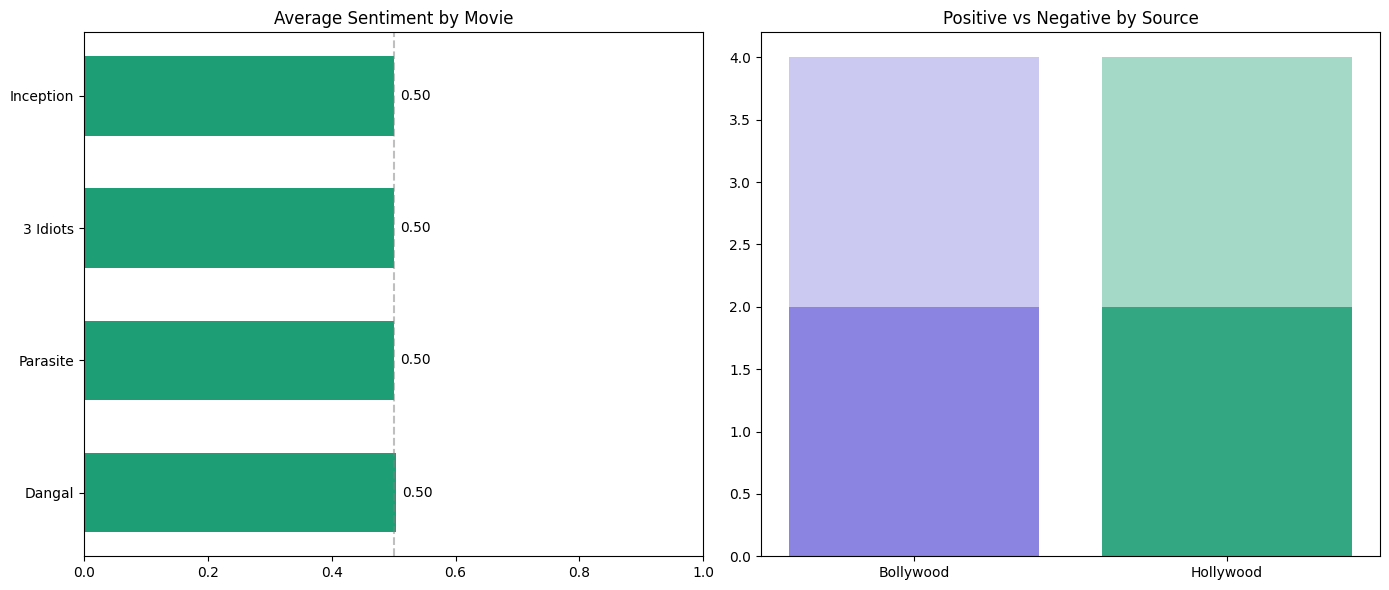

Movie : Stree
Verdict : LOVED IT
Score : 100.0% positive
Review : Rajkummar Rao was phenomenal. A raw, honest performance. Easily the best Hindi f...


{'movie': 'Stree', 'verdict': 'LOVED IT', 'score': 0.9998749494552612}

In [ ]:
import pandas as pd
from transformers import pipeline
reviews_data = [
# Bollywood
{'movie': '3 Idiots', 'source': 'Bollywood',
'review': 'An absolute masterpiece! Makes you laugh and cry. '
'Aamir Khan delivers one of his finest performances ever.'},
{'movie': '3 Idiots', 'source': 'Bollywood',
'review': 'Overrated and preachy. The message was fine but '
'execution felt too theatrical and unrealistic.'},
{'movie': 'Dangal', 'source': 'Bollywood',
'review': 'Incredibly inspiring! Geeta and Babita brought tears '
'to my eyes. Best sports film ever made in India.'},
{'movie': 'Dangal', 'source': 'Bollywood',
'review': 'Good film but very long. Some scenes dragged unnecessarily.'},
# Hollywood
{'movie': 'Inception', 'source': 'Hollywood',
'review': 'Mind-bending and visually stunning. Nolan at his absolutebest.'},
{'movie': 'Inception', 'source': 'Hollywood',
'review': 'Too complicated. I had no idea what was happening half thetime.'},
{'movie': 'Parasite', 'source': 'Hollywood',
'review': 'Perfect film. The class commentary is brilliant. Deserved everyOscar.'},
{'movie': 'Parasite', 'source': 'Hollywood',
'review': 'I expected more from an Oscar winner. Ending felt rushed.'},
]
df = pd.DataFrame(reviews_data)
# Load once — not inside a loop (that would reload weights every iteration)
sentiment = pipeline('sentiment-analysis',
model='distilbert-base-uncased-finetuned-sst-2-english')
# Batch all reviews at once — faster than one-by-one
results = sentiment(df['review'].tolist())
df['sentiment'] = [r['label'] for r in results] # POSITIVE / NEGATIVE
df['confidence'] = [r['score'] for r in results] # 0.0 to 1.0
# sentiment_score: 1.0 = very positive, 0.0 = very negative
df['sentiment_score'] = df['confidence'].where(
df['sentiment'] == 'POSITIVE',
1 - df['confidence']
)
print(df[['movie','sentiment','confidence']].to_string(index=False))
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Chart 1: Average sentiment score per movie
ax1 = axes[0]
movie_scores =df.groupby('movie')['sentiment_score'].mean().sort_values(ascending=False)
colours = ['#1D9E75' if v >= 0.5 else '#D85A30' for v in
movie_scores.values]
bars = ax1.barh(movie_scores.index, movie_scores.values, color=colours,
height=0.6)
ax1.set_xlim(0, 1)
ax1.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax1.set_title('Average Sentiment by Movie')
for bar, val in zip(bars, movie_scores.values):
  ax1.text(val+0.01, bar.get_y()+bar.get_height()/2, f'{val:.2f}',
  va='center')
# Chart 2: Positive vs Negative split by source
  ax2 = axes[1]
for source, colour in [('Bollywood','#7F77DD'), ('Hollywood','#1D9E75')]:
  subset = df[df['source'] == source]
  pos = (subset['sentiment']=='POSITIVE').sum()
  neg = (subset['sentiment']=='NEGATIVE').sum()
  ax2.bar(source, pos, color=colour, alpha=0.9)
  ax2.bar(source, neg, bottom=pos, color=colour, alpha=0.4)
  ax2.set_title('Positive vs Negative by Source')
plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
def analyse_review(review_text, movie_name='Unknown'):
  result = sentiment(review_text)[0]
  label = result['label']
  conf = result['score']
  if label == 'POSITIVE':
    score = conf
    verdict = 'LOVED IT' if conf > 0.95 else 'LIKED IT'
  else:
    score = 1 - conf
    verdict = 'HATED IT' if conf > 0.95 else 'DISLIKED IT'
  print(f'Movie : {movie_name}')
  print(f'Verdict : {verdict}')
  print(f'Score : {score:.1%} positive')
  print(f'Review : {review_text[:80]}...')
  return {'movie': movie_name, 'verdict': verdict, 'score': score}
analyse_review(
'Rajkummar Rao was phenomenal. A raw, honest performance. '
'Easily the best Hindi film of the decade.',
'Stree'
)

**day 19**


In [6]:
pip install anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 923.8/923.8 kB 10.5 MB/s eta 0:00:00


In [ ]:
import anthropic

client = anthropic.Anthropic()
topic = input('What topic do you want to study today? ')
system_prompt = (
    f'You are a friendly, patient study buddy helping a student learn about '
    f'{topic}. Explain concepts simply, use examples, and ask a follow-up '
    f'question after each answer to check understanding. Keep answers under '
    f'150 words.'
)
conversation = []  # stores the full back-and-forth histor

print(f"Study buddy ready! Ask me anything about {topic}.")
print("Type 'quit' to exit.\n")

while True:
    user_input = input('You: ')
    if user_input.lower() == 'quit':
        print('Good luck studying!')
        break

    # Add the user's message to history
    conversation.append({'role': 'user', 'content': user_input})

    # Call the API with full history so the model remembers context
    response = client.messages.create(
        model='claude-sonnet-4-6',
        max_tokens=400,
        system=system_prompt,
        messages=conversation
    )
    reply = response.content[0].text
    print(f'Buddy: {reply}\n')

    # Add the assistant's reply to history too — this is what gives
    # the chatbot 'memory' within this session
    conversation.append({'role': 'assistant', 'content': reply})

** day 20**
Text Summarisation

Build a News Digest Tool

In [ ]:
articles = [
"""Apple unveiled its newest iPhone at an event in Cupertino on
Tuesday.
CEO Tim Cook said the device features a faster chip and improved
camera.
The phone will be available in stores starting next month, the company
said, with prices starting at $999.""",
"""The World Health Organization announced new guidelines on Monday
aimed at reducing sugar consumption worldwide. Officials in Geneva
said
the changes could prevent millions of cases of diabetes over the next
decade if adopted by national governments.""",
"""Tesla reported record deliveries for the third quarter, beating
analyst expectations. The Texas-based company said demand remained
strong in China and Europe despite increased competition from
traditional automakers entering the EV market.""",
"""NASA's Perseverance rover discovered new evidence of ancient
water activity on Mars, according to a paper published this week.
Scientists at the Jet Propulsion Laboratory said the findings
strengthen the case that the planet once had a wetter climate.""",
"""Manchester United announced the signing of a new midfielder
from Barcelona for a reported fee of 80 million euros. The 24-year-old
player will join the club ahead of the new season starting in
August.""",
]


import spacy
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Load each model ONCE — reused for every article
nlp = spacy.load('en_core_web_sm')

# Direct loading for summarization model
summarizer_tokenizer = AutoTokenizer.from_pretrained("sshleifer/distilbart-cnn-12-6")
summarizer_model = AutoModelForSeq2SeqLM.from_pretrained("sshleifer/distilbart-cnn-12-6")
def digest_article(text):
    # Summarise (abstractive, short)
    inputs = summarizer_tokenizer(text, return_tensors="pt", truncation=True, max_length=1024)
    summary_ids = summarizer_model.generate(inputs["input_ids"], num_beams=4, max_length=40, min_length=10, do_sample=False, early_stopping=True)
    summary_text = summarizer_tokenizer.decode(summary_ids[0], skip_special_tokens=True)

    # Extract entities
    doc = nlp(text)
    entities = {}

    for ent in doc.ents:
        entities.setdefault(ent.label_, set()).add(ent.text)

    return summary_text, entities


for i, article in enumerate(articles, 1):
    summary, entities = digest_article(article)

    print(f"--- Article {i} ---")
    print("Summary :", summary)
    print("Entities:")

    for label, names in entities.items():
        print(f"  {label}: {', '.join(names)}")

    print()


config.json:   0%|          | 0.00/1.80k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

--- Article 1 ---
Summary :  CEO Tim Cook said the device features a faster chip and improved camera . The phone will be available in stores starting next month, with prices starting at $999 .
Entities:
  ORG: Apple
  GPE: Cupertino
  DATE: next month, Tuesday
  PERSON: Tim Cook
  MONEY: 999

--- Article 2 ---
Summary :  The World Health Organization announced new guidelines aimed at reducing sugar consumption worldwide . Officials in Geneva said the changes could prevent millions of cases of diabetes over the next decade .
Entities:
  ORG: The World Health Organization
  DATE: the next
decade, Monday
  GPE: Geneva
  CARDINAL: millions

--- Article 3 ---
Summary :  Tesla reported record deliveries for the third quarter, beating analyst expectations . The Texas-based company said demand remained strong in China and Europe .
Entities:
  DATE: the third quarter
  GPE: China, Texas
  LOC: Europe
  ORG: EV

--- Article 4 ---
Summary :  NASA's Perseverance rover discovered new evidence of an